# Cheatsheet — Introducción al Machine Learning (IIND3118)

### Los 19 temas del curso · Python ejecutado + equivalente en R

Notebook de referencia para el parcial con libro abierto. Cada tema incluye:

- **Qué problema resuelve** y la intuición detrás del método
- **Formulación matemática** con las fórmulas que hay que saber
- **Parámetros clave**: qué controla cada uno y cómo elegirlo
- **Ventajas, desventajas** y cuándo el método falla
- **Código en Python** comentado y ya ejecutado, con las salidas guardadas
- **Equivalente en R** en un bloque aparte, para los temas que el profesor dictó en R

La numeración coincide con las carpetas del repositorio (`temas/01-fundamentos/` …
`temas/19-ridge-lasso-elasticnet/`), cada una con su `README.md`, su `codigo.py` y su `codigo.R`.
Este cheatsheet resume ese material, no lo reemplaza.

> **Cómo usarlo:** ejecutar la celda de SETUP una vez y después saltar al tema que se
> necesite. Cada tema es independiente salvo por las variables del SETUP.

---

### Índice

**Parte 1 — Aprendizaje no supervisado**

*Clustering*
1. [Fundamentos: el supuesto i.i.d.](#t01) · 2. [K-Means](#t02) · 3. [Silhouette y métricas](#t03) · 4. [K-Medoides](#t04) · 5. [Jerárquico](#t05) · 6. [DBSCAN](#t06)

*Detección de outliers*
7. [Z-Score y Mahalanobis](#t07) · 8. [LOF e Isolation Forest](#t08)

*Reducción de dimensiones*
9. [PCA](#t09) · 10. [MDS](#t10) · 11. [Análisis factorial](#t11) · 12. [Kernel PCA](#t12) · 13. [SVD](#t13) · 14. [Manifold learning](#t14)

**Parte 2 — Aprendizaje supervisado**

15. [EPE y sesgo-varianza](#t15) · 16. [Kernel regression y k vecinos](#t16) · 17. [Validación cruzada](#t17) · 18. [Selección de variables](#t18) · 19. [Ridge, LASSO y Elastic Net](#t19)

[Resumen final: las trampas](#trampas)

---

### Qué lenguaje usó el curso en cada tema

| Temas | Dictados en | Por qué importa |
|---|---|---|
| 1–8, 14–19 | **Python** | el código del profesor está en los notebooks de clase |
| 9–13 | **R** | PCA, MDS, factorial, KPCA y SVD se vieron con `princomp`, `cmdscale`, `factanal`, `kpca` y `svd` |

En este cheatsheet **todo está en Python ejecutado** (para poder ver las salidas) y además
cada tema trae el **bloque equivalente en R**. Los bloques de R no se ejecutan aquí porque el
kernel del notebook es de Python: están para copiar y pegar.


In [1]:
# ===========================================================================
# SETUP - ejecutar esta celda primero
# ===========================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams["figure.dpi"] = 80
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

# Semilla fija -> resultados reproducibles.
# OJO: la misma semilla en R NO da los mismos numeros (generadores distintos).
RNG = np.random.default_rng(0)

from sklearn.datasets import load_iris, load_diabetes
from sklearn.preprocessing import scale

# --- Datos de la Parte 1 (no supervisado) ---------------------------------
iris   = load_iris()
X_iris = iris.data          # 150 x 4, en centimetros
Xs     = scale(X_iris)      # estandarizado (media 0, sd 1)
y_iris = iris.target        # especies reales: SOLO para verificar, nunca para ajustar

# --- Datos de la Parte 2 (supervisado) ------------------------------------
diab       = load_diabetes()
X_diab     = diab.data      # 442 x 10, ya centrado y escalado por sklearn
y_diab     = diab.target
var_diab   = diab.feature_names

# --- Funcion de la simulacion supervisada (temas 1, 15 y 16) --------------
_A_EXP, _B_FREQ = 0.3, 0.2
def f_optima(x):
    """E[Y|X=x]. En un problema real NO se conoce: aqui se conoce porque se simula."""
    return 2 + x**_A_EXP * np.cos(x/_B_FREQ)

print(f"iris    : n={X_iris.shape[0]:3d}, p={X_iris.shape[1]}   {iris.feature_names}")
print(f"diabetes: n={X_diab.shape[0]:3d}, p={X_diab.shape[1]}  {var_diab}")


iris    : n=150, p=4   ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
diabetes: n=442, p=10  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


<a id="t01"></a>

---
# 1. Fundamentos: el supuesto i.i.d.

## El axioma

Todo el curso descansa sobre un solo supuesto, el mismo de la estadística clásica:

> Los datos son realizaciones **independientes e idénticamente distribuidas** de un modelo de
> probabilidad multivariado que describe el comportamiento poblacional que se quiere generalizar.

La factorización básica:

$$P_{XY}(x,y) = P_X(x)\,P_{Y|X}(y \mid x)$$

Esa factorización separa los dos grandes problemas del curso:

| | Qué se observa | Qué se quiere aprender | Parte del curso |
|---|---|---|---|
| **Supervisado** | pares $(X_i, Y_i)$ | $P_{Y\mid X}$: una función que dado $X$ prediga $Y$ | Parte 2 (temas 15–19) |
| **No supervisado** | solo $X \in \mathbb{R}^p$ | $P_X$: dónde se concentra la masa, si hay grupos, si la dimensión efectiva es menor que $p$ | Parte 1 (temas 1–14) |

**Por qué importa el supuesto:** es el **permiso para generalizar**. Si las observaciones no
vienen de la misma distribución, o están correlacionadas entre sí, lo aprendido en la muestra no
dice nada sobre lo que viene.

## Datos por grupos: la mezcla

Cuando los datos vienen de grupos, la densidad se vuelve una **mezcla**:

$$f(x) = \pi_1 f_1(x) + \pi_2 f_2(x) + \dots + \pi_K f_K(x), \qquad \sum_k \pi_k = 1$$

Esta es exactamente la estructura que los algoritmos de clustering intentan recuperar sin conocer
las etiquetas. **El clustering es un problema de estimar una mezcla, no de clasificar.**

## La descomposición del error (se usa en la Parte 2)

$$Y = f_{opt}(X) + \varepsilon, \qquad E[\varepsilon]=0, \quad \operatorname{Var}(\varepsilon)=\sigma^2$$

con $f_{opt}(x) = E[Y \mid X=x]$. El término $\sigma^2$ es el **error irreducible**: ningún
modelo, por bueno que sea, puede bajar de ahí.

> En una simulación se conoce $f_{opt}$ y $\sigma$. En un problema real no. Por eso las
> simulaciones sirven: permiten comparar la estimación contra la verdad.


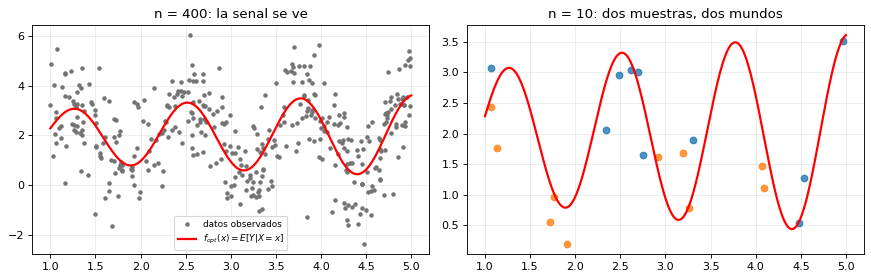

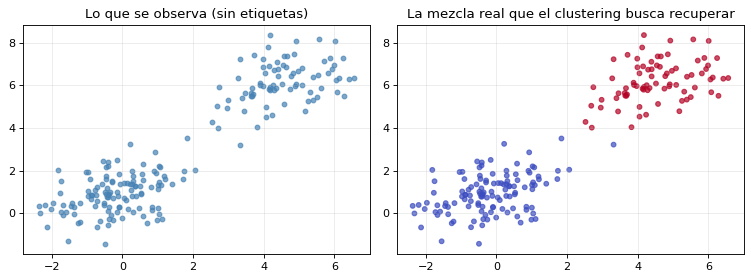

proporciones reales: [0.61 0.39]   (teoricas: [0.6, 0.4])


In [2]:
# ===========================================================================
# 1a. El caso supervisado: f_optima + error irreducible
# ===========================================================================
sigma = 1.2          # error irreducible. f_optima quedo definida en el SETUP

n = 400
x = RNG.uniform(1, 5, n)
y = f_optima(x) + RNG.normal(0, sigma, n)   # sigma = PISO del MSE, ningun modelo lo baja

rejilla = np.linspace(1, 5, 600)

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(x, y, "o", ms=3, color="0.45", label="datos observados")
ax[0].plot(rejilla, f_optima(rejilla), "r", lw=2, label="$f_{opt}(x)=E[Y|X=x]$")
ax[0].set_title(f"n = {n}: la senal se ve"); ax[0].legend(fontsize=8)

# Con n pequeno, dos muestras de LA MISMA poblacion se ven muy distintas.
# Esa es la VARIANZA del estimador, y es la razon de separar train y test.
for color in ["tab:blue", "tab:orange"]:
    xs = RNG.uniform(1, 5, 10)
    ax[1].plot(xs, f_optima(xs) + RNG.normal(0, sigma, 10), "o", ms=6, color=color, alpha=.8)
ax[1].plot(rejilla, f_optima(rejilla), "r", lw=2)
ax[1].set_title("n = 10: dos muestras, dos mundos")
plt.tight_layout(); plt.show()


# ===========================================================================
# 1b. El caso NO supervisado: mezcla de densidades
# ===========================================================================
p1 = 0.6                                  # peso del grupo 1
m1, m2 = np.array([0., 1.]), np.array([4.5, 6.])
cov = np.array([[1., .5], [.5, 1.]])      # 0.5 = correlacion entre X1 y X2
n = 200

grupo = (RNG.random(n) >= p1).astype(int)          # 0 o 1 segun la probabilidad
X = np.where(grupo[:, None] == 0,
             RNG.multivariate_normal(m1, cov, n),
             RNG.multivariate_normal(m2, cov, n))

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.6))
ax[0].scatter(*X.T, color="steelblue", alpha=.7, s=18)
ax[0].set_title("Lo que se observa (sin etiquetas)")
ax[1].scatter(*X.T, c=grupo, cmap="coolwarm", alpha=.7, s=18)
ax[1].set_title("La mezcla real que el clustering busca recuperar")
plt.tight_layout(); plt.show()

print(f"proporciones reales: {np.bincount(grupo)/n}   (teoricas: [{p1}, {1-p1:.1f}])")


<a id="t02"></a>

---
# 2. K-Means

## Qué resuelve

**Clustering** es partir las $n$ observaciones en grupos excluyentes que puedan interpretarse como
un bloque. No hay un criterio objetivo único: se busca simultáneamente **separación** entre grupos
y **coherencia** dentro de ellos, y cada algoritmo define esas dos cosas distinto. K-Means define
la coherencia como la distancia al centro.

## Formulación

Con $K$ fijo, se minimiza la suma de distancias al cuadrado al centro del grupo:

$$\min_{z} \sum_{i=1}^{n}\sum_{k=1}^{K} z_{ik}\,\lVert x_i - \bar{x}_k \rVert^2, \qquad
\bar{x}_k = \frac{1}{n_k}\sum_{i} z_{ik}\, x_i$$

sujeto a $\sum_k z_{ik}=1$ y $z_{ik}\in\{0,1\}$.

### Dos equivalencias que suelen preguntar

**1. Distancias al centro = distancias por pares.** Al usar el promedio como centroide:

$$\sum_{x \in C_k} \lVert x - \bar{x}_k\rVert^2 = \frac{1}{2 n_k}\sum_{x \in C_k}\sum_{y \in C_k} \lVert x - y\rVert^2$$

**2. La identidad ANOVA (la fórmula clave):**

$$\underbrace{\sum_i \lVert x_i - \bar{X}\rVert^2}_{\text{SST (fija)}} =
\underbrace{\sum_k n_k \lVert \bar{x}_k - \bar{X}\rVert^2}_{\text{BSS (entre grupos)}} +
\underbrace{\sum_k \sum_{x \in C_k} \lVert x - \bar{x}_k\rVert^2}_{\text{WSS (dentro, el error)}}$$

SST **no depende de la partición**. Entonces **minimizar WSS equivale a maximizar BSS**: coherencia
interna y separación entre grupos son el mismo criterio visto de dos formas.

## El algoritmo

El problema exacto es **NP-Hard** para $p>2$. Se usa una heurística **greedy** que alterna dos
pasos hasta que el SSE deja de cambiar:

1. Dados los centros, asignar cada punto al centro más cercano.
2. Dada la asignación, recalcular cada centro como el promedio del grupo.

Converge a un **mínimo local**, así que se repite con varias inicializaciones y se escoge la mejor
(`n_init` en sklearn, `nstart` en R).

## Problemas

1. Riesgo de traslape en las fronteras entre grupos.
2. Los clusters tienden a ser **bolas** de tamaño parecido: falla con formas irregulares.
3. **No es robusto**: un solo outlier arrastra el promedio.
4. **Depende de la escala**: la variable con mayor rango domina la distancia. **Estandarizar siempre.**

## Cómo elegir K

- **Método del codo:** graficar WSS contra $K$ y buscar donde la ganancia marginal se aplana. El WSS *siempre* baja (con $K=n$ es cero), así que no se puede minimizar.
- **Métricas externas:** Silhouette, Calinski-Harabasz, Davies-Bouldin (tema 3).

## Equivalente en R

```r
Xs <- scale(iris[, 1:4])          # escalar es fundamental

set.seed(0)
km <- kmeans(Xs, centers = 3, nstart = 25)   # nstart = n_init de sklearn

km$centers        # centroides, una fila por grupo
km$cluster        # etiquetas
km$tot.withinss   # WSS = SSE (el inertia_ de sklearn)
km$betweenss      # BSS
km$totss          # SST = BSS + WSS

# Metodo del codo
sse <- sapply(1:10, function(k) kmeans(Xs, centers = k, nstart = 25)$tot.withinss)
plot(1:10, sse, type = "b", xlab = "K", ylab = "WSS")
```


Centroides (una FILA por grupo, en unidades z):
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0              -0.05             -0.88               0.35              0.28
1              -1.01              0.85              -1.30             -1.25
2               1.14              0.09               1.00              1.02

SST = 600.00 = BSS (460.18) + WSS (139.82)
BSS/SST = 0.767   <- minimizar WSS es lo mismo que maximizar BSS
iteraciones hasta converger: 3
SSE manual  : 140.9015  (8 iteraciones)
SSE sklearn : 139.8205
misma particion: False


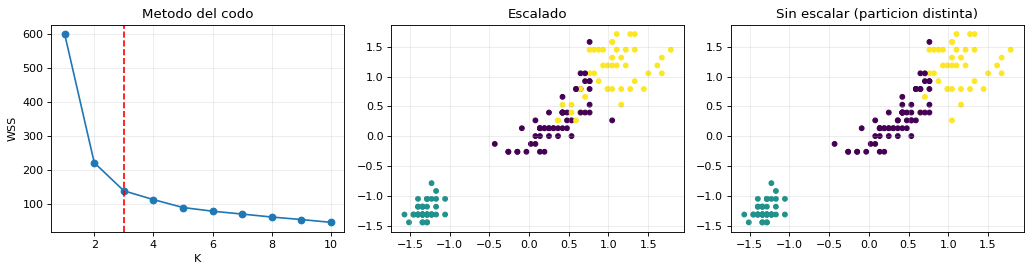

particiones escalado vs crudo, tabla cruzada:
col_0   0   1   2
row_0            
0      52   0   1
1       0  50   0
2      10   0  37


In [3]:
# ===========================================================================
# 2a. K-Means con scikit-learn + verificacion de la identidad ANOVA
# ===========================================================================
from sklearn.cluster import KMeans

km = KMeans(
    n_clusters=3,       # K: hay que fijarlo de antemano
    n_init=10,          # 10 arranques aleatorios -> se queda con el de menor WSS
    init="k-means++",   # inicializacion inteligente
    random_state=0,
).fit(Xs)               # OJO: Xs esta ESTANDARIZADO

print("Centroides (una FILA por grupo, en unidades z):")
print(pd.DataFrame(km.cluster_centers_, columns=iris.feature_names).round(2).to_string())

SST = np.sum((Xs - Xs.mean(0))**2)
WSS = km.inertia_                 # exactamente lo que el algoritmo minimiza
BSS = SST - WSS
print(f"\nSST = {SST:.2f} = BSS ({BSS:.2f}) + WSS ({WSS:.2f})")
print(f"BSS/SST = {BSS/SST:.3f}   <- minimizar WSS es lo mismo que maximizar BSS")
print(f"iteraciones hasta converger: {km.n_iter_}")


# ===========================================================================
# 2b. El algoritmo a mano: alternar asignacion y recalculo de centros
# ===========================================================================
def kmeans_manual(X, K, tol=1e-8, max_iter=300, semilla=0):
    rng = np.random.default_rng(semilla)
    n, p = X.shape
    Z = np.zeros((n, K)); Z[np.arange(n), rng.integers(0, K, n)] = 1   # asignacion inicial
    historia = []
    for _ in range(max_iter):
        n_k = Z.sum(0)
        centros = (X.T @ Z) / np.where(n_k == 0, 1, n_k)       # p x K
        D = ((X[:, :, None] - centros[None])**2).sum(1)        # n x K, distancias^2
        Z = np.zeros((n, K)); Z[np.arange(n), D.argmin(1)] = 1  # paso de asignacion
        sse = np.sum(D * Z)                                     # solo la distancia al grupo propio
        historia.append(sse)
        if len(historia) > 1 and historia[-2] - sse < tol:
            break
    return Z.argmax(1), np.array(historia)

etiq_man, hist = kmeans_manual(Xs, 3)
print(f"SSE manual  : {hist[-1]:.4f}  ({len(hist)} iteraciones)")
print(f"SSE sklearn : {km.inertia_:.4f}")
print("misma particion:", len(set(zip(etiq_man, km.labels_))) == 3)


# ===========================================================================
# 2c. Metodo del codo + el efecto de NO escalar
# ===========================================================================
wss = [KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xs).inertia_ for k in range(1, 11)]

km_crudo = KMeans(n_clusters=3, n_init=10, random_state=0).fit(X_iris)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
ax[0].plot(range(1, 11), wss, "o-"); ax[0].axvline(3, color="r", ls="--")
ax[0].set_xlabel("K"); ax[0].set_ylabel("WSS"); ax[0].set_title("Metodo del codo")
ax[1].scatter(Xs[:, 2], Xs[:, 3], c=km.labels_, cmap="viridis", s=18)
ax[1].set_title("Escalado")
ax[2].scatter(Xs[:, 2], Xs[:, 3], c=km_crudo.labels_, cmap="viridis", s=18)
ax[2].set_title("Sin escalar (particion distinta)")
plt.tight_layout(); plt.show()

print("particiones escalado vs crudo, tabla cruzada:")
print(pd.crosstab(km.labels_, km_crudo.labels_).to_string())


<a id="t03"></a>

---
# 3. Silhouette y métricas de validación

## El problema

En clustering no hay etiqueta verdadera. ¿Cómo saber si una partición es buena? ¿Cómo escoger $K$?

- **Internas al algoritmo** (método del codo): usan la función objetivo que el algoritmo optimiza, así que no permiten comparar métodos distintos.
- **Externas al algoritmo** (Silhouette, CH, DB): no se refieren a esa función objetivo, así que **sí permiten comparar entre algoritmos**.

Ninguna resuelve el problema por completo. Todas son heurísticas y a menudo se contradicen.

## Silhouette

Se calcula **por observación**:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\,b(i)\}} \in [-1, 1]$$

- $a(i)$ = distancia promedio de $i$ a los demás puntos de **su** cluster → **cohesión**
- $b(i)$ = distancia promedio de $i$ al cluster **más cercano distinto** → **separación**

| Valor | Interpretación |
|---|---|
| $s(i) \approx 1$ | mucho más cerca de su grupo que del vecino: buena asignación |
| $s(i) \approx 0$ | en la frontera entre dos grupos |
| $s(i) < 0$ | **más cerca de otro grupo que del propio**: mala asignación |

El Silhouette global es el promedio de los $s(i)$.

## Calinski-Harabasz

Razón entre dispersión externa e interna, ajustada por grados de libertad. Es una idea tipo $F$ de ANOVA:

$$CH = \frac{BSS/(K-1)}{WSS/(n-K)}$$

## Davies-Bouldin

Para cada cluster toma el peor par (dispersión interna sobre separación de centros) y promedia.

## Resumen operativo

| Métrica | Dirección | Rango | Supone |
|---|---|---|---|
| Silhouette | **máximo** | $[-1,1]$ | clusters convexos |
| Calinski-Harabasz | **máximo** | $[0,\infty)$ | clusters convexos y separados por centroides |
| Davies-Bouldin | **mínimo** | $[0,\infty)$ | clusters convexos |

> **La trampa importante:** las tres asumen grupos compactos alrededor de un centroide. Con
> anillos concéntricos los centroides coinciden, así que **premian a K-Means sobre DBSCAN aunque
> DBSCAN sea el que acierta**. Las métricas describen la geometría de $X$, no la verdad.

## Equivalente en R

```r
library(cluster)
Xs  <- scale(iris[, 1:4])
dis <- dist(Xs)
km  <- kmeans(Xs, 3, nstart = 25)

sil <- silhouette(km$cluster, dis)
summary(sil)          # promedio global y por cluster
plot(sil, col = 1:3)  # el grafico de silhouette
mean(sil[, 3])        # silhouette promedio

library(fpc)
cluster.stats(dis, km$cluster)$ch      # Calinski-Harabasz (maximo)

library(clusterSim)
index.DB(Xs, km$cluster)$DB            # Davies-Bouldin (minimo)
```


  K | Silhouette | Calinski-H |  Davies-B
------------------------------------------
  2 |      0.582 |      251.3 |     0.593
  3 |      0.460 |      241.9 |     0.834
  4 |      0.387 |      207.3 |     0.870
  5 |      0.346 |      203.3 |     0.945
  6 |      0.326 |      187.1 |     1.052
  7 |      0.332 |      175.9 |     1.065
  8 |      0.345 |      173.3 |     0.887

mejor K segun Silhouette : 2
mejor K segun Calinski-H : 2
mejor K segun Davies-B   : 2

OJO: prefieren K=2 aunque iris tenga 3 especies. Las metricas describen
la GEOMETRIA de X, no la taxonomia: versicolor y virginica se traslapan.


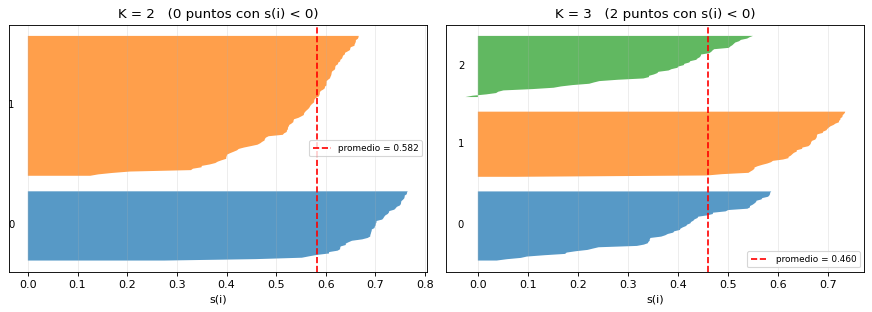

metodo   | Silhouette | Calinski-H | ARI real
----------------------------------------------
K-Means  |      0.331 |      265.4 |   -0.002
DBSCAN   |      0.153 |        0.0 |    1.000

DBSCAN acierta (ARI = 1) pero las metricas lo castigan: asumen grupos
compactos alrededor de un centroide, y en anillos los centroides coinciden.


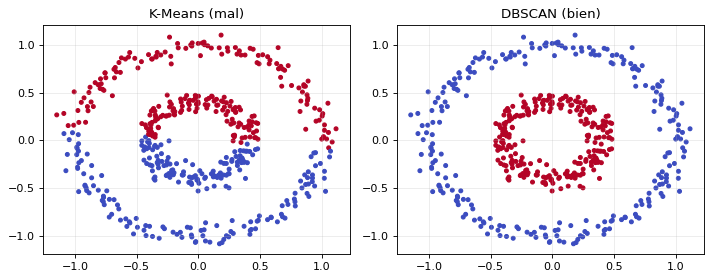

In [4]:
# ===========================================================================
# 3a. Las tres metricas en funcion de K
# ===========================================================================
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             calinski_harabasz_score, davies_bouldin_score)

print(f"{'K':>3} | {'Silhouette':>10} | {'Calinski-H':>10} | {'Davies-B':>9}")
print("-"*42)
res = {}
for k in range(2, 9):
    lab = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Xs)
    res[k] = (silhouette_score(Xs, lab),        # MAXIMIZAR
              calinski_harabasz_score(Xs, lab), # MAXIMIZAR
              davies_bouldin_score(Xs, lab))    # MINIMIZAR
    print(f"{k:3d} | {res[k][0]:10.3f} | {res[k][1]:10.1f} | {res[k][2]:9.3f}")

print(f"\nmejor K segun Silhouette : {max(res, key=lambda k: res[k][0])}")
print(f"mejor K segun Calinski-H : {max(res, key=lambda k: res[k][1])}")
print(f"mejor K segun Davies-B   : {min(res, key=lambda k: res[k][2])}")
print("\nOJO: prefieren K=2 aunque iris tenga 3 especies. Las metricas describen")
print("la GEOMETRIA de X, no la taxonomia: versicolor y virginica se traslapan.")


# ===========================================================================
# 3b. Grafico de silhouette a mano (sin yellowbrick)
# ===========================================================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, K in zip(axes, [2, 3]):
    lab = KMeans(n_clusters=K, n_init=10, random_state=0).fit_predict(Xs)
    s_i = silhouette_samples(Xs, lab)     # el s(i) de CADA observacion
    y0 = 10
    for k in range(K):
        sk = np.sort(s_i[lab == k])
        ax.fill_betweenx(np.arange(y0, y0+len(sk)), 0, sk, alpha=.75)
        ax.text(-0.04, y0 + len(sk)/2, str(k), va="center", fontsize=9)
        y0 += len(sk) + 10
    ax.axvline(s_i.mean(), color="r", ls="--", label=f"promedio = {s_i.mean():.3f}")
    ax.set_title(f"K = {K}   ({(s_i < 0).sum()} puntos con s(i) < 0)")
    ax.set_xlabel("s(i)"); ax.set_yticks([]); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


# ===========================================================================
# 3c. La trampa: las metricas castigan a DBSCAN en formas irregulares
# ===========================================================================
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

Xc, yc = make_circles(n_samples=500, factor=.4, noise=.06, random_state=0)
lab_km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xc)
lab_db = DBSCAN(eps=.2, min_samples=5).fit_predict(Xc)

from sklearn.metrics import adjusted_rand_score
print(f"{'metodo':8} | {'Silhouette':>10} | {'Calinski-H':>10} | {'ARI real':>8}")
print("-"*46)
for nombre, lab in [("K-Means", lab_km), ("DBSCAN", lab_db)]:
    print(f"{nombre:8} | {silhouette_score(Xc, lab):10.3f} | "
          f"{calinski_harabasz_score(Xc, lab):10.1f} | {adjusted_rand_score(yc, lab):8.3f}")

print("\nDBSCAN acierta (ARI = 1) pero las metricas lo castigan: asumen grupos")
print("compactos alrededor de un centroide, y en anillos los centroides coinciden.")

fig, ax = plt.subplots(1, 2, figsize=(9, 3.6))
ax[0].scatter(*Xc.T, c=lab_km, cmap="coolwarm", s=12); ax[0].set_title("K-Means (mal)")
ax[1].scatter(*Xc.T, c=lab_db, cmap="coolwarm", s=12); ax[1].set_title("DBSCAN (bien)")
plt.tight_layout(); plt.show()


<a id="t04"></a>

---
# 4. K-Medoides (PAM)

## Qué cambia

K-Means con un solo cambio: en vez del **promedio**, el centro es el **medoide**, la observación
real de la muestra que es más central dentro del grupo:

$$\text{medoide}_k = \arg\min_{x_j \in C_k} \sum_{x_i \in C_k} d(x_i, x_j)$$

Ese cambio aparentemente menor tiene dos consecuencias grandes:

1. **Robustez.** El promedio se mueve con un solo punto extremo. El medoide no puede, porque está obligado a ser una observación existente.
2. **Generalidad.** El promedio solo tiene sentido con coordenadas euclidianas. El medoide **solo necesita una matriz de distancias**, lo que habilita variables categóricas, ordinales o mixtas.

El algoritmo estándar es **PAM** (*Partitioning Around Medoids*). En el código se usa **FasterPAM**,
una implementación moderna mucho más rápida.

## La distancia de Gower

Con variables de tipos distintos no existe una distancia euclidiana natural. Gower calcula una
disimilitud por variable, normalizada a $[0,1]$, y las promedia:

$$d_{\text{Gower}}(x_i, x_j) = \frac{1}{p}\sum_{v=1}^{p} d_v(x_{iv}, x_{jv})$$

donde $d_v$ es la diferencia absoluta reescalada por el rango (continuas) o una indicadora de
desigualdad (categóricas).

## Costo

PAM evalúa intercambios de medoides, así que es **más costoso que K-Means**. Además hay que
guardar la matriz de distancias completa, que crece como $n^2$: ese es el cuello de botella real
con $n$ grande. Para muestras grandes existe **CLARA**, que aplica PAM sobre submuestras.

## Equivalente en R

```r
library(cluster)

# Caso euclidiano
Xs  <- scale(iris[, 1:4])
pam_res <- pam(Xs, k = 3)

pam_res$medoids     # coordenadas de los medoides
pam_res$id.med      # indices dentro de la muestra
pam_res$clustering  # etiquetas
pam_res$objective   # funcion objetivo
plot(silhouette(pam_res))

# Caso NO euclidiano: datos mixtos con Gower
xx  <- read.table("sponge.txt", header = TRUE, sep = ",")
dis <- daisy(xx, metric = "gower")        # <- el paso clave
pam_gower <- pam(dis, k = 3, diss = TRUE)

# CLARA: PAM sobre submuestras, para n grande
clara(Xs, k = 3, samples = 50)$medoids
```


In [5]:
# ===========================================================================
# 4a. K-Medoides (FasterPAM): la entrada es la MATRIZ DE DISTANCIAS
# ===========================================================================
import kmedoids
from scipy.spatial.distance import pdist, squareform

# Esa es la fuente de su generalidad: aqui es euclidiana, pero podria ser
# Gower, Manhattan, coseno o cualquier disimilitud a medida.
D = squareform(pdist(Xs, metric="euclidean"))      # n x n
print(f"matriz de distancias: {D.shape}  ({D.nbytes/1e6:.2f} MB)")
print("^ crece como n^2: ese es el cuello de botella con n grande\n")

pam = kmedoids.fasterpam(D, 3)
print(f"perdida (suma de distancias a los medoides): {pam.loss:.3f}")
print(f"indices de los medoides: {pam.medoids}   <- son OBSERVACIONES REALES")
print(pd.DataFrame(X_iris[pam.medoids], columns=iris.feature_names,
                   index=[f"medoide {i}" for i in range(3)]).round(2).to_string())


# ===========================================================================
# 4b. Robustez: un solo outlier mueve el promedio, no el medoide
# ===========================================================================
Xr = np.vstack([Xs, [[20., 20., 20., 20.]]])       # un punto absurdo
Dr = squareform(pdist(Xr))

cen_km  = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xr).cluster_centers_
med_pam = Xr[kmedoids.fasterpam(Dr, 3).medoids]

print("Centros con el outlier dentro (primeras dos coordenadas):")
print(f"  K-Means    : {np.round(cen_km[:, :2], 2).tolist()}")
print(f"  K-Medoides : {np.round(med_pam[:, :2], 2).tolist()}")
print("\nK-Means se lleva un centro al outlier y desperdicia un grupo entero.")


# ===========================================================================
# 4c. Distancia de Gower a mano (datos mixtos)
# ===========================================================================
def gower(df):
    """Disimilitud de Gower: por variable se normaliza a [0,1] y se promedia.
    Continuas -> |xi - xj| / rango.   Categoricas -> 0 si igual, 1 si distinto."""
    n = len(df)
    acum = np.zeros((n, n))
    for col in df.columns:
        v = df[col].to_numpy()
        if pd.api.types.is_numeric_dtype(df[col]):
            rango = v.max() - v.min()
            d = np.abs(v[:, None] - v[None, :]) / (rango if rango else 1)
        else:
            d = (v[:, None] != v[None, :]).astype(float)
        acum += d
    return acum / len(df.columns)

mixto = pd.DataFrame({
    "edad":    [25, 41, 33, 58, 29, 47],
    "ingreso": [2.1, 5.4, 3.0, 8.8, 2.4, 6.1],
    "ciudad":  ["BOG", "MDE", "BOG", "CLO", "BOG", "MDE"],   # nominal
    "estrato": [3, 5, 3, 6, 3, 5],
})
Dg = gower(mixto)
print("Matriz de Gower (0 = identicos, 1 = maximamente distintos):")
print(pd.DataFrame(Dg).round(3).to_string())
print("\nEtiquetas con K-Medoides sobre Gower:", kmedoids.fasterpam(Dg, 2).labels)
print("K-Means NO puede hacer esto: no existe el promedio de 'BOG' y 'MDE'.")


matriz de distancias: (150, 150)  (0.18 MB)
^ crece como n^2: ese es el cuello de botella con n grande

perdida (suma de distancias a los medoides): 130.733
indices de los medoides: [  7  94 147]   <- son OBSERVACIONES REALES
           sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
medoide 0                5.0               3.4                1.5               0.2
medoide 1                5.6               2.7                4.2               1.3
medoide 2                6.5               3.0                5.2               2.0
Centros con el outlier dentro (primeras dos coordenadas):
  K-Means    : [[0.51, -0.43], [20.0, 20.0], [-1.01, 0.85]]
  K-Medoides : [[0.8, -0.13], [-1.02, 0.79], [-0.29, -0.82]]

K-Means se lleva un centro al outlier y desperdicia un grupo entero.
Matriz de Gower (0 = identicos, 1 = maximamente distintos):
       0      1      2      3      4      5
0  0.000  0.661  0.094  1.000  0.041  0.733
1  0.661  0.000  0.567  0.589  0.620  0.0

<a id="t05"></a>

---
# 5. Clustering jerárquico

## Qué hace distinto

Los métodos jerárquicos no buscan tanto una partición final en $K$ grupos, sino **mostrar el
proceso** por el cual las observaciones se agregan. El resultado es un **árbol**, no una asignación.

- **Aglomerativo** (*bottom-up*, el usado en la práctica): cada observación empieza sola y en cada paso se fusionan los dos clusters más cercanos.
- **Divisivo** (*top-down*): se empieza con un cluster y se va partiendo. Mucho más costoso.

El algoritmo es **greedy**: toma la mejor fusión local sin reconsiderar. Una vez dos puntos quedan
juntos, **ya no se separan**.

## El concepto central: el linkage

Para fusionar hace falta una distancia **entre grupos**, no entre puntos:

| Linkage | Definición | Comportamiento |
|---|---|---|
| **single** | $\min_{x\in A, y\in B} d(x,y)$ | detecta formas alargadas; sufre *chaining*: una cadena de puntos intermedios une grupos que deberían estar separados |
| **complete** | $\max_{x\in A, y\in B} d(x,y)$ | clusters compactos de diámetro similar; sensible a outliers (un punto extremo define el máximo) |
| **average** | $\frac{1}{\lvert A\rvert \lvert B\rvert}\sum\sum d(x,y)$ | compromiso entre los dos anteriores |
| **ward** | minimiza el incremento de WSS al fusionar | grupos de varianza parecida; es el más cercano a K-Means |

## El dendrograma

El eje vertical es la **altura de fusión**: la distancia a la que se unieron dos grupos. Cortar a
una altura $h$ produce una partición. Un **salto grande de altura** entre dos fusiones sugiere un
buen número de clusters.

## Características y problemas

**A favor:** rápido de implementar, da información adicional (una relación de familias entre los
puntos, útil para visualizar) y es **más robusto que K-Means** a los atípicos.

**En contra:**
1. El resultado **depende mucho del linkage** escogido. No es un detalle: `single` y `ward` pueden dar particiones completamente distintas sobre los mismos datos.
2. Al ser greedy, puede dar soluciones malas en coherencia o separación, porque nunca deshace una fusión.
3. Depende de la escala, igual que K-Means.

## Equivalente en R

```r
Xs  <- scale(iris[, 1:4])
dis <- dist(Xs, method = "euclidean")

hc_single   <- hclust(dis, method = "single")
hc_complete <- hclust(dis, method = "complete")
hc_average  <- hclust(dis, method = "average")
hc_ward     <- hclust(dis, method = "ward.D2")   # ojo: ward.D2, no ward

plot(hc_ward, labels = FALSE)
rect.hclust(hc_ward, k = 3, border = 2:4)        # dibuja el corte

grupos <- cutree(hc_ward, k = 3)                 # = fcluster(..., 'maxclust')
table(grupos, iris$Species)

library(cluster)
ag <- agnes(Xs, method = "ward")   # aglomerativo
di <- diana(Xs)                    # divisivo
```


linkage    |     tamanos de grupo | ARI vs especies
----------------------------------------------------
single     |        [100  49   1] |           0.558
complete   |           [77 24 49] |           0.573
average    |           [50  3 97] |           0.562
ward       |           [49 30 71] |           0.615


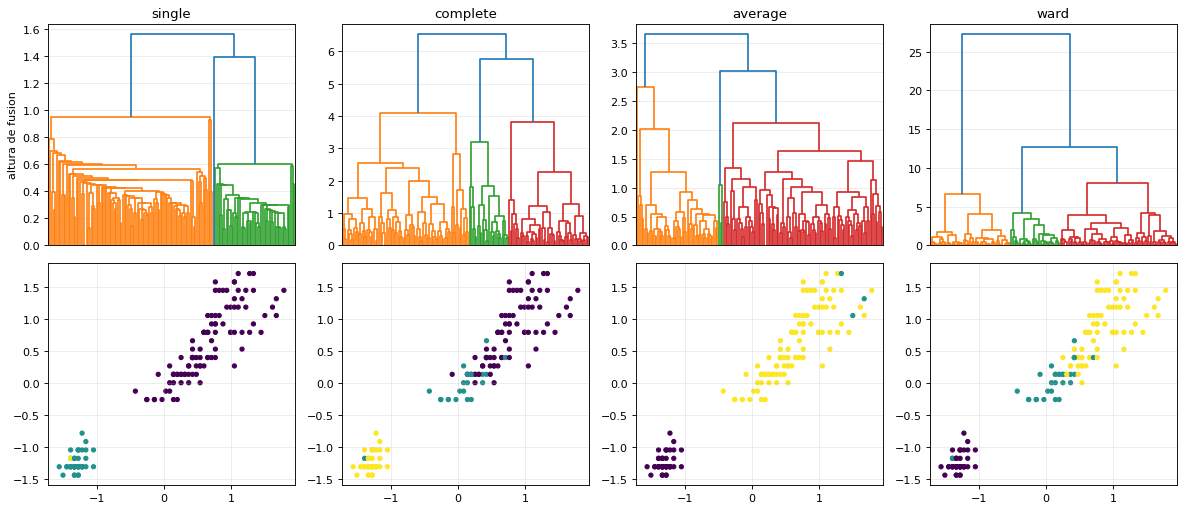


single encadena: junta casi todo en un grupo y deja los otros diminutos.
ward es el mas parecido a K-Means (minimiza el incremento de WSS al fusionar).

ultimas alturas de fusion: [ 3.44  3.93  3.95  4.06  4.23  4.24  6.61  8.   12.64 27.25]
mayor salto -> cortar en K = 2


In [6]:
# ===========================================================================
# 5. Clustering jerarquico: el linkage lo cambia todo
# ===========================================================================
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import adjusted_rand_score

fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))

print(f"{'linkage':10} | {'tamanos de grupo':>20} | {'ARI vs especies':>15}")
print("-"*52)
for j, metodo in enumerate(["single", "complete", "average", "ward"]):
    # linkage() devuelve la matriz de fusiones: [cluster_a, cluster_b, altura, tamano]
    Z = linkage(Xs, method=metodo, metric="euclidean")

    # fcluster corta el arbol. maxclust + t=3 -> pide exactamente 3 grupos
    etiq = fcluster(Z, t=3, criterion="maxclust")
    ari  = adjusted_rand_score(y_iris, etiq)
    print(f"{metodo:10} | {str(np.bincount(etiq)[1:]):>20} | {ari:15.3f}")

    dendrogram(Z, ax=axes[0, j], no_labels=True, color_threshold=Z[-2, 2])
    axes[0, j].set_title(metodo)
    axes[0, j].set_ylabel("altura de fusion" if j == 0 else "")
    axes[1, j].scatter(Xs[:, 2], Xs[:, 3], c=etiq, cmap="viridis", s=14)
plt.tight_layout(); plt.show()

print("\nsingle encadena: junta casi todo en un grupo y deja los otros diminutos.")
print("ward es el mas parecido a K-Means (minimiza el incremento de WSS al fusionar).")

# El salto de altura sugiere donde cortar: la mayor diferencia entre fusiones
Z = linkage(Xs, method="ward")
alturas = Z[-10:, 2]
saltos = np.diff(alturas)
print(f"\nultimas alturas de fusion: {np.round(alturas, 2)}")
print(f"mayor salto -> cortar en K = {len(alturas) - int(np.argmax(saltos))}")


<a id="t06"></a>

---
# 6. DBSCAN

## La idea

Un cluster es una aglomeración de puntos **densamente conectados**, sin necesidad de que todos los
puntos del grupo estén cercanos entre sí.

Esa última frase es la clave. En K-Means todo punto debe estar cerca del centroide. En DBSCAN
basta con que exista una **cadena de vecindades densas** que conecte dos puntos, aunque estén en
extremos opuestos del cluster. Por eso detecta **formas irregulares**: espirales, medialunas,
anillos concéntricos.

*DBSCAN* = *Density-Based Spatial Clustering of **Applications with Noise***. Ese "with Noise"
importa: es el único algoritmo de clustering del curso que puede decir **"este punto no va en
ninguna parte"**.

## Los dos parámetros

Se construye una bola de radio $\varepsilon$ alrededor de cada punto:

1. **`eps` ($\varepsilon$)**: el radio de la vecindad.
2. **`MinPts` (`min_samples`)**: el mínimo de puntos dentro de la vecindad para considerar que el punto está en el interior de un grupo.

## Clasificación de los puntos

| Tipo | Condición |
|---|---|
| **Core** (interno) | su vecindad de radio $\varepsilon$ contiene al menos `MinPts` puntos |
| **Border** (borde) | no es core, pero está dentro de la vecindad de algún core |
| **Noise** (ruido) | ni core ni border |

> El ruido recibe la etiqueta **`-1` en sklearn** y **`0` en el paquete `dbscan` de R**. Es una
> diferencia que se cobra en los parciales.

## Cómo escoger eps

Procedimiento del curso: para un $k$ dado, calcular la distancia de cada punto a su $k$-ésimo
vecino más cercano, ordenar esas distancias y graficarlas. **El codo de esa curva sugiere el
$\varepsilon$.** Dónde cortar depende de qué proporción de outliers se esté dispuesto a aceptar:
si se corta bajo, más puntos quedan como ruido.

## Ventajas y desventajas

**A favor:** detecta formas irregulares, no hay que fijar $K$, identifica outliers explícitamente,
es robusto al ruido.

**En contra:**
- Los parámetros son **difíciles de calibrar** y el resultado es muy sensible a ellos.
- Falla cuando los clusters tienen **densidades muy distintas**: un solo par $(\varepsilon, \text{MinPts})$ no sirve para todos. (Para eso existe **OPTICS**.)
- Se degrada en dimensión alta, porque las distancias se concentran.

## Equivalente en R

```r
library(dbscan)
X <- as.matrix(iris[, 1:4])

kNNdistplot(X, k = 5)               # la curva k-dist
abline(h = 0.6, col = "red", lty = 2)

db <- dbscan(X, eps = 0.6, minPts = 6)
db$cluster                          # OJO: el ruido es 0 en R, no -1
table(db$cluster)

plot(X[, 3], X[, 4], col = db$cluster + 1L, pch = 16)

# OPTICS: la version que tolera densidades variables
op <- optics(X, eps = 2, minPts = 6)
plot(op)
```


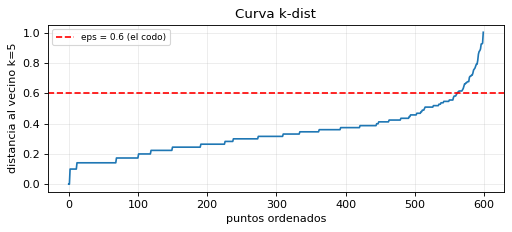

  eps | clusters |  ruido |  % ruido
------------------------------------
  0.3 |        2 |    106 |    70.7%
  0.4 |        4 |     32 |    21.3%
  0.6 |        2 |     11 |     7.3%
  0.8 |        2 |      2 |     1.3%
  1.2 |        2 |      0 |     0.0%


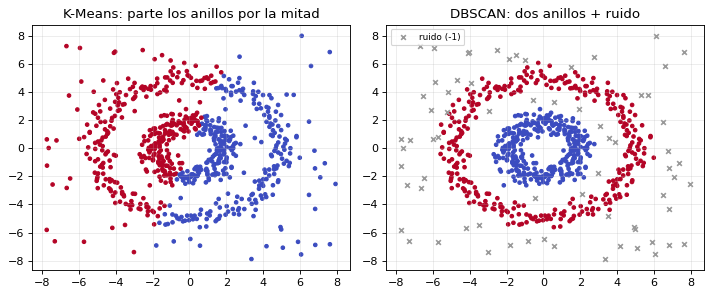

DBSCAN: 2 clusters, 69 puntos de ruido (se inyectaron 100)


In [7]:
# ===========================================================================
# 6a. Calibracion de eps con la curva k-dist
# ===========================================================================
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

k = 5
nn = NearestNeighbors(n_neighbors=k).fit(X_iris)
# kneighbors devuelve el punto mismo como primer vecino (distancia 0): se descarta con [:,1:]
d_k = np.sort(nn.kneighbors(X_iris)[0][:, 1:].reshape(-1))

plt.figure(figsize=(6.5, 3))
plt.plot(d_k); plt.axhline(.6, color="r", ls="--", label="eps = 0.6 (el codo)")
plt.xlabel("puntos ordenados"); plt.ylabel(f"distancia al vecino k={k}")
plt.title("Curva k-dist"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


# ===========================================================================
# 6b. Sensibilidad a eps: el parametro lo decide TODO
# ===========================================================================
print(f"{'eps':>5} | {'clusters':>8} | {'ruido':>6} | {'% ruido':>8}")
print("-"*36)
for eps in [.3, .4, .6, .8, 1.2]:
    lab = DBSCAN(eps=eps, min_samples=6).fit_predict(X_iris)
    n_cl = len(set(lab)) - (1 if -1 in lab else 0)    # -1 no cuenta como cluster
    n_ru = int((lab == -1).sum())
    print(f"{eps:5.1f} | {n_cl:8d} | {n_ru:6d} | {n_ru/len(lab):8.1%}")


# ===========================================================================
# 6c. Donde DBSCAN gana: formas irregulares y ruido explicito
# ===========================================================================
theta = np.linspace(0, 2*np.pi, 300)
r1, r2 = 2 + RNG.normal(0, .4, 300), 5 + RNG.normal(0, .4, 300)
Xi = np.vstack([np.c_[r1*np.cos(theta), r1*np.sin(theta)],
                np.c_[r2*np.cos(theta), r2*np.sin(theta)],
                RNG.uniform(-8, 8, (100, 2))])         # ruido uniforme de fondo

lab_db = DBSCAN(eps=.7, min_samples=8).fit_predict(Xi)
lab_km = KMeans(n_clusters=2, n_init=10, random_state=0).fit_predict(Xi)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].scatter(*Xi.T, c=lab_km, cmap="coolwarm", s=10)
ax[0].set_title("K-Means: parte los anillos por la mitad")
ax[1].scatter(*Xi[lab_db != -1].T, c=lab_db[lab_db != -1], cmap="coolwarm", s=10)
ax[1].scatter(*Xi[lab_db == -1].T, c="0.6", marker="x", s=18, label="ruido (-1)")
ax[1].set_title("DBSCAN: dos anillos + ruido"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"DBSCAN: {len(set(lab_db)) - 1} clusters, {(lab_db == -1).sum()} puntos de ruido "
      f"(se inyectaron 100)")


<a id="t07"></a>

---
# 7. Outliers: Z-Score y Mahalanobis

## El problema

Buscar observaciones que se comportan distinto al resto. Es **no supervisado**: no hay una $Y$ que
diga cuáles son atípicos. Aplicaciones del curso: detección de fraude, vigilancia, pérdida de
presión en tuberías de petróleo.

> **Un outlier estadístico no es automáticamente un error ni un fraude.** Es una observación
> improbable *bajo el modelo asumido*. Con $n$ grande **siempre** habrá puntos en las colas: es lo
> que se espera de una distribución. Qué significa depende del contexto, y eso no lo resuelve
> ningún algoritmo.

## Z-Score (una dimensión)

$$Z(x_i) = \frac{x_i - \bar{x}}{sd(x_1,\dots,x_n)}$$

Regla habitual: $\lvert Z\rvert > 3$.

### El problema del enmascaramiento

El outlier participa en el cálculo de $\bar{x}$ y de $sd$. Un punto extremo **infla la desviación y
se esconde a sí mismo**; con un grupo de outliers el efecto se agrava y todos se enmascaran
mutuamente.

La solución es la versión robusta, con mediana y **MAD** (*median absolute deviation*):

$$Z_{mod}(x_i) = \frac{0.6745\,(x_i - \text{med}(x))}{\text{MAD}(x)}, \qquad
\text{MAD}(x) = \text{med}\bigl(\lvert x_i - \text{med}(x)\rvert\bigr)$$

Tiene **punto de ruptura del 50%**: hasta la mitad de los datos pueden estar contaminados sin que
el estimador se rompa.

## Mahalanobis (caso multivariado)

El Z-Score aplicado variable por variable **no detecta outliers multivariados**: un punto puede ser
perfectamente normal en cada variable por separado y aun así ser imposible dada la correlación
entre ellas.

$$d_M(x)^2 = (x-\mu)^{\top} S^{-1} (x-\mu)$$

Es la distancia euclidiana **después de blanquear** los datos, es decir, después de quitarles la
correlación y estandarizar cada dirección. Los contornos de igual distancia son las **elipses** de
la distribución, no círculos.

Bajo normalidad multivariada:

$$d_M^2 \sim \chi^2_p \quad\Longrightarrow\quad \text{atípico si } d_M^2 > \chi^2_{p,\,0.975}$$

> Mahalanobis también se enmascara, porque $\bar{x}$ y $S$ se estiman con los outliers dentro. La
> versión robusta usa **MCD** (*minimum covariance determinant*).

## Por qué se pasa a métodos locales

Ambos métodos asumen **una sola nube de datos con un centro**. Si hay varios grupos o densidades
distintas, fallan. Ese es el motivo del tema 8.

## Equivalente en R

```r
# Z-Score
z <- scale(muestra)                     # (x - mean)/sd
which(abs(z) > 3)

# Z modificado (robusto)
z_mod <- 0.6745*(muestra - median(muestra)) / mad(muestra, constant = 1)

# Mahalanobis: OJO, devuelve la distancia AL CUADRADO
X  <- as.matrix(iris[, 1:4])
d2 <- mahalanobis(X, center = colMeans(X), cov = var(X))

umbral <- qchisq(0.975, df = ncol(X))
which(d2 > umbral)

qqplot(qchisq(ppoints(nrow(X)), df = ncol(X)), d2)   # diagnostico
abline(0, 1, col = "red")

# Version robusta con MCD
library(MASS)
rob <- cov.rob(X, method = "mcd")
which(mahalanobis(X, rob$center, rob$cov) > umbral)
```


 n outliers |  Z clasico |  detecta? |  Z modificado
----------------------------------------------------
          1 |       8.42 |        si |          29.0
          2 |       6.13 |        si |          28.9
          5 |       3.95 |        si |          28.0
         10 |       2.81 |        NO |          23.7
         15 |       2.30 |        NO |          20.6

Los outliers inflan la sd y se esconden entre si. El Z modificado
(mediana + MAD) no se contamina: punto de ruptura del 50%.
El punto inyectado: Z por variable = [2.16 2.14]  -> ninguno pasa de 3
                    d_M^2          = 71.0   umbral chi2(2) = 7.38  -> ATIPICO

total de atipicos por Mahalanobis: 4 de 301 (1.3%, esperado ~2.5%)


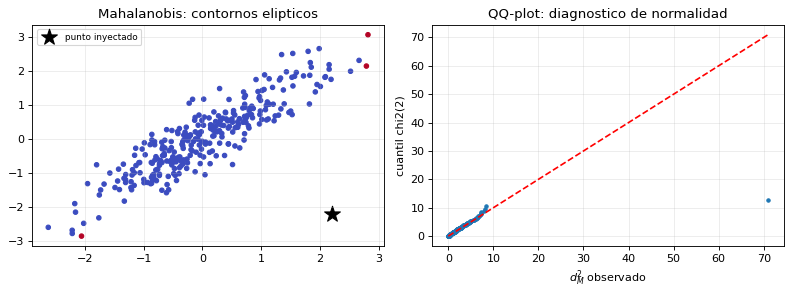

In [8]:
# ===========================================================================
# 7a. Enmascaramiento: el Z-Score falla con GRUPOS de outliers
# ===========================================================================
base, extremo = RNG.normal(5, 1.5, 80), 40.0

print(f"{'n outliers':>11} | {'Z clasico':>10} | {'detecta?':>9} | {'Z modificado':>13}")
print("-"*52)
for k in [1, 2, 5, 10, 15]:
    m = np.append(base, [extremo]*k)
    z_cla = (extremo - m.mean()) / m.std(ddof=0)                 # usa media y sd
    mad   = np.median(np.abs(m - np.median(m)))                  # robusto
    z_mod = 0.6745 * (extremo - np.median(m)) / mad
    print(f"{k:11d} | {z_cla:10.2f} | {'si' if abs(z_cla) > 3 else 'NO':>9} | {z_mod:13.1f}")

print("\nLos outliers inflan la sd y se esconden entre si. El Z modificado")
print("(mediana + MAD) no se contamina: punto de ruptura del 50%.")


# ===========================================================================
# 7b. Mahalanobis: por que no basta mirar variable por variable
# ===========================================================================
from scipy.stats import chi2

mu, S_ = np.array([0., 0.]), np.array([[1., .9], [.9, 1.]])   # correlacion alta
Xm = RNG.multivariate_normal(mu, S_, 300)
Xm = np.vstack([Xm, [[2.2, -2.2]]])          # tipico en cada eje, IMPOSIBLE en conjunto

z_por_var = np.abs((Xm - Xm.mean(0)) / Xm.std(0))
centrado  = Xm - Xm.mean(0)
S_inv     = np.linalg.inv(np.cov(Xm, rowvar=False))
d2        = np.einsum("ij,jk,ik->i", centrado, S_inv, centrado)   # d_M^2 de cada punto

umbral = chi2.ppf(.975, df=2)
print(f"El punto inyectado: Z por variable = {np.round(z_por_var[-1], 2)}  -> ninguno pasa de 3")
print(f"                    d_M^2          = {d2[-1]:.1f}   umbral chi2(2) = {umbral:.2f}  -> ATIPICO")
print(f"\ntotal de atipicos por Mahalanobis: {(d2 > umbral).sum()} de {len(Xm)} "
      f"({(d2 > umbral).mean():.1%}, esperado ~2.5%)")

fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
ax[0].scatter(*Xm.T, c=(d2 > umbral), cmap="coolwarm", s=16)
ax[0].scatter(*Xm[-1], marker="*", s=220, color="k", label="punto inyectado")
ax[0].set_title("Mahalanobis: contornos elipticos"); ax[0].legend(fontsize=8)
ax[1].plot(np.sort(d2), chi2.ppf((np.arange(len(d2))+.5)/len(d2), 2), "o", ms=3)
lims = [0, max(d2.max(), umbral*2)]
ax[1].plot(lims, lims, "r--"); ax[1].set_xlabel("$d_M^2$ observado")
ax[1].set_ylabel("cuantil chi2(2)"); ax[1].set_title("QQ-plot: diagnostico de normalidad")
plt.tight_layout(); plt.show()


<a id="t08"></a>

---
# 8. Outliers: LOF e Isolation Forest

Los métodos del tema 7 detectan outliers **globales**: puntos lejos del centro de toda la muestra.
Pero muchos atípicos reales son **locales**: un punto normal globalmente que resulta extraño
respecto a su vecindad inmediata. Estos dos métodos atacan el problema desde ángulos **opuestos**.

## Local Outlier Factor (LOF)

Método basado en **densidades**. Compara la densidad local de una observación con la de sus
vecinos. Tres pasos:

**1. Distancia de alcanzabilidad** (*reachability distance*):

$$RD_k(x,y) = \max\{\,d_k(y),\ d(x,y)\,\}$$

donde $d_k(y)$ es la distancia de $y$ a su $k$-ésimo vecino. Es una distancia *suavizada*: reduce
la varianza de la estimación de densidad.

**2. Densidad local alcanzable:**

$$lrd_k(x) = \left(\frac{1}{\lvert N_k(x)\rvert}\sum_{y\in N_k(x)} RD_k(x,y)\right)^{-1}$$

El inverso de la distancia promedio a los $k$ vecinos: alta cuando los vecinos están cerca.

**3. El factor LOF:**

$$LOF_k(x) = \frac{1}{\lvert N_k(x)\rvert}\sum_{y\in N_k(x)} \frac{lrd_k(y)}{lrd_k(x)}$$

| Valor | Interpretación |
|---|---|
| $LOF \approx 1$ | densidad similar a la de sus vecinos: **normal** |
| $LOF \gg 1$ | mucho menos denso que sus vecinos: **outlier** |
| $LOF < 1$ | está en una zona más densa que sus vecinos |

> **En sklearn hay una trampa de signo:** `negative_outlier_factor_` es $-LOF$. Más negativo =
> más atípico. Un punto normal da un valor cercano a $-1$.

El parámetro crítico es $k$ (`n_neighbors`): define **qué tan local** es el análisis.

## Isolation Forest

Método basado en árboles. La idea: hacer **particiones aleatorias y paralelas a los ejes** hasta
aislar una observación. Los puntos anómalos son **más fáciles de separar**, o sea que requieren
menos particiones.

$$h(x) = \text{número de particiones necesarias para aislar } x$$

Se promedia $h(x)$ sobre muchos árboles y se normaliza en un score:

$$s(x,m) \to 1 \;\Rightarrow\; \text{outlier}, \qquad s(x,m) \approx 0.5 \;\Rightarrow\; \text{normal}$$

> **Otra trampa de signo:** `decision_function` de sklearn invierte esa escala. **Negativo =
> anómalo**, positivo = normal.

**Ventajas:** no calcula distancias, así que escala muy bien en $n$ y en $p$; es rápido; y a
diferencia de LOF se puede **ajustar en una muestra y aplicar a otra**.

## Cuándo usar cuál

| Situación | Método |
|---|---|
| una sola nube, pocas dimensiones | Mahalanobis |
| varios grupos con densidades distintas | **LOF** |
| muchos datos o muchas dimensiones | **Isolation Forest** |

## Equivalente en R

```r
library(dbscan)
X <- as.matrix(iris[, 1:4])

# LOF: aqui devuelve el LOF DIRECTO, no negado como en sklearn
puntajes <- lof(X, minPts = 5)
which(puntajes > 1.5)                # > 1 = atipico

plot(X[, 3], X[, 4], pch = 16, cex = puntajes,
     col = ifelse(puntajes > 1.5, "red", "black"))

# Isolation Forest: el score va de 0 a 1, cerca de 1 = outlier
library(isotree)
modelo <- isolation.forest(as.data.frame(X), ntrees = 100)
scores <- predict(modelo, as.data.frame(X))
which(scores > 0.6)
```


metodo             | marcados |  inyectados detectados
------------------------------------------------------
LOF                |       21 |             9 / 10
Isolation Forest   |       50 |            10 / 10

LOF de un punto normal ~ 1 (aqui negativo: -1.05)
LOF del outlier mas extremo         : -9.89


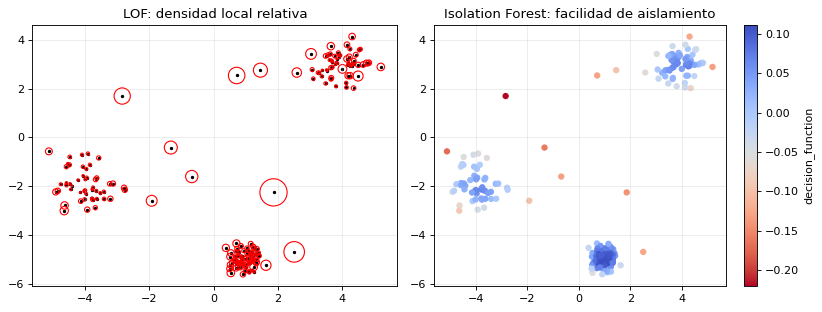


LOF necesita distancias (se degrada en dimension alta).
Isolation Forest no las calcula: escala mucho mejor en n y en p.


In [9]:
# ===========================================================================
# 8. LOF (densidad local) contra Isolation Forest (facilidad de aislamiento)
# ===========================================================================
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest

# Tres grupos con DENSIDADES DISTINTAS (0.5, 0.3, 0.5) + outliers dispersos.
# Las densidades distintas son justo lo que un metodo global no maneja.
Xo = np.vstack([[-4, -2] + .5*RNG.standard_normal((50, 2)),
                [ 1, -5] + .3*RNG.standard_normal((80, 2)),
                [ 4,  3] + .5*RNG.standard_normal((60, 2)),
                2.5*RNG.standard_normal((10, 2))])
n_out = 10                                    # los ultimos 10 son los inyectados

lof = LocalOutlierFactor(n_neighbors=5)       # k: EL parametro critico
y_lof = lof.fit_predict(Xo)                   # -1 = outlier, 1 = inlier
s_lof = lof.negative_outlier_factor_          # OJO: es -LOF (mas negativo = mas atipico)

iso = IsolationForest(n_estimators=100, random_state=0).fit(Xo)
y_iso = iso.predict(Xo)                       # -1 / 1
s_iso = iso.decision_function(Xo)             # negativo = anomalo (signo invertido vs teoria)

print(f"{'metodo':18} | {'marcados':>8} | {'inyectados detectados':>22}")
print("-"*54)
for nom, yy in [("LOF", y_lof), ("Isolation Forest", y_iso)]:
    print(f"{nom:18} | {int((yy == -1).sum()):8d} | {int((yy[-n_out:] == -1).sum()):>13d} / {n_out}")

print(f"\nLOF de un punto normal ~ 1 (aqui negativo: {s_lof[0]:.2f})")
print(f"LOF del outlier mas extremo         : {s_lof.min():.2f}")

# Radio proporcional al score: circulo grande = mas atipico
fig, ax = plt.subplots(1, 2, figsize=(10.5, 4))
radio = (s_lof.max() - s_lof) / (s_lof.max() - s_lof.min())
ax[0].scatter(*Xo.T, c="k", s=4)
ax[0].scatter(*Xo.T, s=600*radio, facecolors="none", edgecolors="r")
ax[0].set_title("LOF: densidad local relativa")
sc = ax[1].scatter(*Xo.T, c=s_iso, cmap="coolwarm_r", s=22)
plt.colorbar(sc, ax=ax[1], label="decision_function")
ax[1].set_title("Isolation Forest: facilidad de aislamiento")
plt.tight_layout(); plt.show()

print("\nLOF necesita distancias (se degrada en dimension alta).")
print("Isolation Forest no las calcula: escala mucho mejor en n y en p.")


<a id="t09"></a>

---
# 9. PCA (componentes principales)

> Este tema y los cuatro siguientes se dictaron **en R**. El código en Python está abajo para
> poder ver las salidas; el bloque de R es el que corresponde al material del curso.

## El problema de la reducción de dimensiones

Datos en una matriz $X$ de $n\times p$. **La dimensionalidad que preocupa es $p$**, no $n$:

- No se puede visualizar más allá de 2 o 3 dimensiones
- Las variables suelen estar correlacionadas: hay **redundancia**
- **Maldición de la dimensionalidad:** en dimensión alta las distancias se concentran y todo método basado en distancia se degrada
- Con $p$ grande los modelos sobreajustan

El criterio de "mejor representación" del curso es **conservar las relaciones entre los puntos**:

$$\text{Dist}(x_i, x_j) \;\approx\; \text{Dist}(z_i, z_j) \qquad \forall\, i,j$$

## Formulación

PCA es **lineal**: $Z = XA$ con $A \in \mathbb{R}^{p\times d}$. Se busca la dirección unitaria $w$
que **maximiza la varianza de la proyección**:

$$\max_{\lVert w\rVert = 1} \operatorname{Var}(Xw) = \max_{\lVert w\rVert=1} w^{\top} S\, w$$

La solución sale de la **descomposición espectral** de la covarianza $S = W\Lambda W^{\top}$:

- $w_1$ = primer autovector ⟹ dirección de máxima varianza
- $\lambda_j$ = **la varianza del componente $j$**
- el componente $j$ es ortogonal a todos los anteriores

**Scores** (las nuevas coordenadas): $\;Z = (X - \bar{X})\,W$

**Varianza explicada** por el componente $j$: $\;\lambda_j / \sum_i \lambda_i$

**Reconstrucción** con $d$ componentes: $\;\hat{X} = Z_d W_d^{\top} + \bar{X}$. Con $d = p$ es exacta.
Este es el principio de la compresión de imágenes del ejemplo de dígitos.

## Decisiones prácticas

| Decisión | Regla |
|---|---|
| **Centrar** | siempre. PCA sin centrar mide otra cosa |
| **Escalar** | si las unidades difieren. En R, `princomp(..., cor = TRUE)` o `prcomp(..., scale. = TRUE)` |
| **Cuántos componentes** | gráfico de codo de los autovalores, varianza acumulada sobre un umbral, o regla de Kaiser ($\lambda > 1$ sobre la correlación) |
| **Interpretar** | biplot: scores de las observaciones más flechas de las cargas |

> **El signo de un componente es arbitrario:** $-w$ explica exactamente la misma varianza que $w$.
> Por eso dos implementaciones pueden dar gráficos reflejados sin que ninguna esté mal.

> **Transposición:** `pca.components_` de sklearn tiene una **fila** por componente;
> `prcomp$rotation` de R tiene una **columna** por componente.

## Equivalente en R (el código del curso)

```r
data <- read.table("measure.txt")
X <- data[, 1:3]

# --- A mano, con la descomposicion espectral ---
S <- var(X)
eigen(S)
w      <- eigen(S)$vectors[, 1]      # primer componente
lambda <- eigen(S)$values[1]         # su varianza

XX <- as.matrix(scale(X, center = TRUE, scale = FALSE))   # centrados
Z  <- XX %*% w                                            # scores

lambda / sum(eigen(S)$values)        # proporcion de varianza explicada

# --- Con la funcion ---
pca <- princomp(X, scores = TRUE)
summary(pca, loadings = TRUE)
pca$scores
pca$sdev^2                           # autovalores

plot(pca$sdev^2, type = "b", main = "Varianzas de Componentes")   # codo
biplot(pca)

# prcomp usa SVD y es numericamente mas estable
pr <- prcomp(X, center = TRUE, scale. = TRUE)
pr$rotation      # cargas, una COLUMNA por componente
pr$x             # scores
cumsum(pr$sdev^2)/sum(pr$sdev^2)
which(pr$sdev^2 > 1)                 # regla de Kaiser
```


Varianza explicada por componente:
  PC1: lambda =  4.2282   (92.46%)   acumulada = 92.46%
  PC2: lambda =  0.2427   ( 5.31%)   acumulada = 97.77%
  PC3: lambda =  0.0782   ( 1.71%)   acumulada = 99.48%
  PC4: lambda =  0.0238   ( 0.52%)   acumulada = 100.00%

Cargas (loadings):
                     PC1    PC2    PC3    PC4
sepal length (cm)  0.361  0.657 -0.582  0.315
sepal width (cm)  -0.085  0.730  0.598 -0.320
petal length (cm)  0.857 -0.173  0.076 -0.480
petal width (cm)   0.358 -0.075  0.546  0.754

PC1 carga parejo en todo salvo el ancho del sepalo: es un eje de TAMANO.
autovalores a mano : [4.2282 0.2427 0.0782 0.0238]
de sklearn         : [4.2282 0.2427 0.0782 0.0238]
cargas iguales salvo signo: True

El signo de un componente es ARBITRARIO: -w explica la misma varianza que w.
varianza de PC1 sin escalar: 92.5%
varianza de PC1 escalando  : 73.0%
Sin escalar, la variable de mayor varianza numerica domina el primer componente.


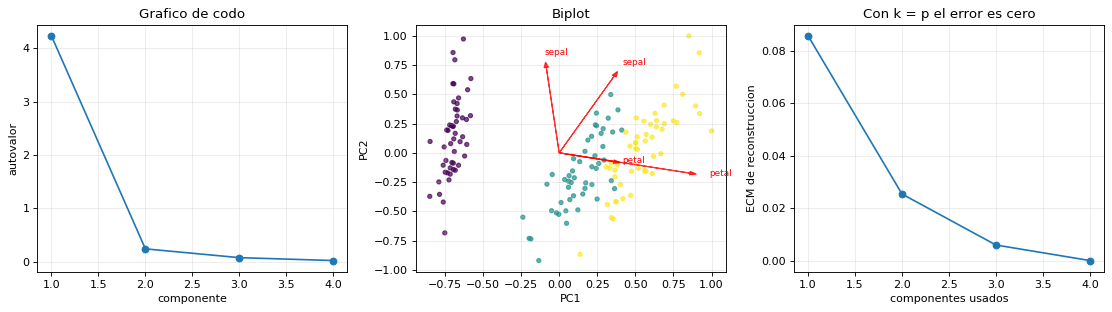


error de reconstruccion por k: [0.0856  0.02534 0.00592 0.     ]


In [10]:
# ===========================================================================
# 9a. PCA: cargas, varianza explicada y scores
# ===========================================================================
from sklearn.decomposition import PCA

pca = PCA(n_components=None).fit(X_iris)     # None = todos los componentes
Z = pca.transform(X_iris)                    # Z = los SCORES

print("Varianza explicada por componente:")
acum = np.cumsum(pca.explained_variance_ratio_)
for i, (lam, r) in enumerate(zip(pca.explained_variance_, pca.explained_variance_ratio_), 1):
    print(f"  PC{i}: lambda = {lam:7.4f}   ({r:6.2%})   acumulada = {acum[i-1]:6.2%}")

# pca.components_ tiene forma (componentes, variables): una FILA por componente.
# En R, prcomp$rotation tiene una COLUMNA por componente. Estan transpuestas.
cargas = pd.DataFrame(pca.components_.T,
                      columns=[f"PC{i+1}" for i in range(4)],
                      index=iris.feature_names)
print("\nCargas (loadings):")
print(cargas.round(3).to_string())
print("\nPC1 carga parejo en todo salvo el ancho del sepalo: es un eje de TAMANO.")


# ===========================================================================
# 9b. A mano con la descomposicion espectral (debe coincidir salvo el signo)
# ===========================================================================
S = np.cov(X_iris, rowvar=False)
val, vec = np.linalg.eigh(S)              # eigh: S es simetrica, devuelve ascendente
orden = np.argsort(val)[::-1]
val, vec = val[orden], vec[:, orden]

print(f"autovalores a mano : {np.round(val, 4)}")
print(f"de sklearn         : {np.round(pca.explained_variance_, 4)}")
print(f"cargas iguales salvo signo: {np.allclose(np.abs(vec), np.abs(pca.components_.T))}")
print("\nEl signo de un componente es ARBITRARIO: -w explica la misma varianza que w.")


# ===========================================================================
# 9c. Escalar o no, biplot y error de reconstruccion
# ===========================================================================
pca_s = PCA().fit(Xs)
print(f"varianza de PC1 sin escalar: {pca.explained_variance_ratio_[0]:.1%}")
print(f"varianza de PC1 escalando  : {pca_s.explained_variance_ratio_[0]:.1%}")
print("Sin escalar, la variable de mayor varianza numerica domina el primer componente.")

fig, ax = plt.subplots(1, 3, figsize=(14, 4))
ax[0].plot(range(1, 5), pca.explained_variance_, "o-")
ax[0].set_xlabel("componente"); ax[0].set_ylabel("autovalor"); ax[0].set_title("Grafico de codo")

# Biplot: scores + flechas de las variables originales
esc = Z[:, :2] / np.abs(Z[:, :2]).max(0)
ax[1].scatter(*esc.T, c=y_iris, cmap="viridis", s=14, alpha=.7)
for i, nom in enumerate(iris.feature_names):
    ax[1].arrow(0, 0, pca.components_[0, i], pca.components_[1, i], color="r",
                head_width=.03, alpha=.8)
    ax[1].text(pca.components_[0, i]*1.15, pca.components_[1, i]*1.15,
               nom.split()[0][:5], color="r", fontsize=8)
ax[1].set_xlabel("PC1"); ax[1].set_ylabel("PC2"); ax[1].set_title("Biplot")

# Reconstruccion: X ~ Z_k W_k' + media
errores = []
for k in range(1, 5):
    X_rec = Z[:, :k] @ pca.components_[:k] + X_iris.mean(0)
    errores.append(np.mean((X_iris - X_rec)**2))
ax[2].plot(range(1, 5), errores, "o-")
ax[2].set_xlabel("componentes usados"); ax[2].set_ylabel("ECM de reconstruccion")
ax[2].set_title("Con k = p el error es cero")
plt.tight_layout(); plt.show()

print(f"\nerror de reconstruccion por k: {np.round(errores, 5)}")


<a id="t10"></a>

---
# 10. Multidimensional Scaling (MDS)

## El problema que resuelve

Suponga que **no tiene las coordenadas** $X$, pero sí las **distancias entre observaciones**, en
una matriz $D$ de $n\times n$. ¿Se puede recuperar un mapa de los puntos?

El ejemplo canónico es `eurodist`: se conocen las distancias por carretera entre ciudades europeas
y MDS **reconstruye el mapa de Europa sin haber visto jamás una latitud ni una longitud**.

Es más general de lo que parece. Muchas veces las distancias son lo único disponible: similitud
entre productos por co-compras, disimilitud percibida entre marcas en una encuesta, distancia
genética entre especies.

## La intuición fundamental

La clave es la relación entre **distancias y productos punto**. Si los datos están centrados, la
matriz $B = XX^{\top}$ se recupera de las distancias al cuadrado por **doble centrado**:

$$B = -\tfrac{1}{2}\,C\,D^{(2)}\,C, \qquad C = I - \tfrac{1}{n}\mathbf{1}\mathbf{1}^{\top}$$

Con $B = V\Lambda V^{\top}$, las coordenadas salen de:

$$X = V_{[:,1:d]}\;\Lambda_{[1:d]}^{1/2}$$

## Los tres sabores

| Tipo | Cuándo | Función |
|---|---|---|
| **Clásico** (métrico) | distancias euclidianas | `cmdscale` |
| **Métrico** | distancias cuantitativas no euclidianas, por ejemplo Gower sobre datos mixtos | `cmdscale` sobre `daisy` |
| **No métrico** (Kruskal) | solo importa el **orden** de las distancias: percepción, similitud, votaciones | `isoMDS` de MASS |

> **Resultado importante:** con distancias euclidianas, **MDS clásico es equivalente a PCA**. Da
> las mismas coordenadas salvo rotación y reflexión. La diferencia está en la entrada: PCA recibe
> $X$, MDS recibe $D$.

## Diagnósticos

- `mds$eig`: los autovalores. **Autovalores negativos grandes indican que $D$ no es euclidiana.** La proporción de los primeros $d$ mide la calidad del mapa.
- **Estrés** (en el no métrico): $<5\%$ excelente, $>20\%$ malo.
- **Diagrama de Shepard:** distancias originales contra distancias del mapa. Debe caer sobre la diagonal.

> **La ambigüedad de rotación y reflexión es inherente al método**, no un error. Por eso el código
> del curso escribe `y <- -mds$points[,2]`: solo para poner el norte arriba.

## Equivalente en R (el código del curso)

```r
# --- 1. Clasico ---
mds <- cmdscale(eurodist, k = 2, eig = TRUE)
x <- mds$points[, 1]
y <- -mds$points[, 2]                 # reflejar para que el norte quede arriba

plot(x, y, type = "n", asp = 1, axes = FALSE, main = "cmdscale(eurodist)")
text(x, y, rownames(mds$points), cex = 0.6)

mds$eig                                # autovalores: diagnostico
sum(abs(mds$eig[1:2]))/sum(abs(mds$eig))   # informacion retenida

# --- 2. Metrico sobre datos MIXTOS ---
library(cluster)
xx  <- read.table("sponge.txt", header = TRUE, sep = ",")
dis <- daisy(xx, metric = "gower")     # <- el paso clave del tema
mds <- cmdscale(dis, k = 2, eig = TRUE)
plot(mds$points)

# --- 3. No metrico (solo el orden importa) ---
library(MASS); library(HSAUR2)
mds <- isoMDS(voting)
mds$stress                             # en porcentaje
plot(mds$points, type = "n")
text(mds$points, rownames(mds$points), cex = 0.6)
```


coordenadas MDS == scores PCA (salvo signo): True
primeros autovalores de B: [630.01  36.16  11.65   3.55]
informacion retenida en 2D: 97.77%


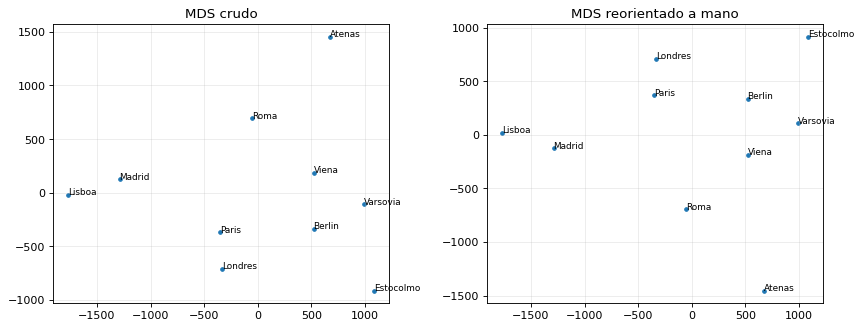

correlacion entre distancias originales y del mapa: 0.9984


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_mds.py:779: FutureWarning: Use metric_mds=False instead of metric=False. The support for metric={True/False} will be dropped in 1.10.
  warnings.warn(


estres normalizado del MDS no metrico: 0.0410
regla practica: < 0.05 excelente, > 0.20 malo


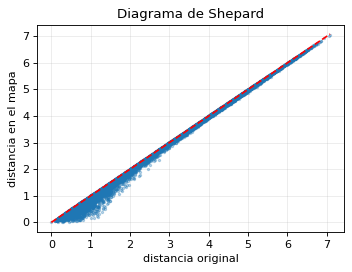

In [11]:
# ===========================================================================
# 10a. MDS clasico implementado desde la formula
# ===========================================================================
from scipy.spatial.distance import pdist, squareform

def cmdscale(D, k=2):
    """MDS clasico, equivalente a cmdscale() de R.
    Recupera coordenadas SOLO desde la matriz de distancias:
      1. Doble centrado : B = -1/2 * C D^2 C,  con C = I - (1/n) 11'
      2. Descomposicion espectral de B
      3. Coordenadas    : V_k * sqrt(Lambda_k)
    """
    D = np.asarray(D, float); n = len(D)
    C = np.eye(n) - np.ones((n, n))/n
    B = -0.5 * C @ (D**2) @ C
    val, vec = np.linalg.eigh(B)
    o = np.argsort(val)[::-1]
    val, vec = val[o], vec[:, o]
    pos = val[:k] > 0                       # solo autovalores positivos dan coordenadas reales
    coord = np.zeros((n, k))
    coord[:, pos] = vec[:, :k][:, pos] * np.sqrt(val[:k][pos])
    return coord, val

# Resultado clave: con distancias euclidianas, MDS clasico == PCA
D_iris = squareform(pdist(X_iris))
coord, autoval = cmdscale(D_iris, 2)
Z_pca = PCA(n_components=2).fit_transform(X_iris)

print(f"coordenadas MDS == scores PCA (salvo signo): "
      f"{np.allclose(np.abs(coord), np.abs(Z_pca), atol=1e-8)}")
print(f"primeros autovalores de B: {np.round(autoval[:4], 2)}")
print(f"informacion retenida en 2D: {autoval[:2].sum()/np.abs(autoval).sum():.2%}")


# ===========================================================================
# 10b. El ejemplo canonico: reconstruir un mapa solo con distancias
# ===========================================================================
# Coordenadas aproximadas (grados). Se usan SOLO para fabricar las distancias
# y para comparar al final: el algoritmo nunca las ve.
ciudades = {"Lisboa": (38.7, -9.1),  "Madrid": (40.4, -3.7),  "Paris": (48.9, 2.4),
            "Londres": (51.5, -0.1), "Berlin": (52.5, 13.4),  "Roma": (41.9, 12.5),
            "Viena": (48.2, 16.4),   "Varsovia": (52.2, 21.0),
            "Estocolmo": (59.3, 18.1), "Atenas": (38.0, 23.7)}
nombres = list(ciudades)
latlon  = np.radians(np.array(list(ciudades.values())))

# Distancia de gran circulo (haversine), en km
dlat = latlon[:, None, 0] - latlon[None, :, 0]
dlon = latlon[:, None, 1] - latlon[None, :, 1]
h = np.sin(dlat/2)**2 + np.cos(latlon[:, 0])[:, None]*np.cos(latlon[:, 0])[None, :]*np.sin(dlon/2)**2
D_ciu = 2*6371*np.arcsin(np.sqrt(h))

mapa, _ = cmdscale(D_ciu, 2)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.2))
# El mapa sale rotado o reflejado: eso es INHERENTE al metodo, no un error.
for signo, a, titulo in [(1, ax[0], "MDS crudo"), (-1, ax[1], "MDS reorientado a mano")]:
    xx, yy = mapa[:, 0], signo*mapa[:, 1]
    a.scatter(xx, yy, s=10)
    for i, nom in enumerate(nombres):
        a.text(xx[i], yy[i], nom, fontsize=8)
    a.set_title(titulo); a.set_aspect("equal")
plt.tight_layout(); plt.show()


# ===========================================================================
# 10c. Diagnostico: diagrama de Shepard y estres
# ===========================================================================
from sklearn.manifold import MDS

d_orig = pdist(X_iris)
d_mds  = pdist(coord)
print(f"correlacion entre distancias originales y del mapa: {np.corrcoef(d_orig, d_mds)[0,1]:.4f}")

mds_nm = MDS(n_components=2, metric=False, dissimilarity="precomputed",
             normalized_stress=True, random_state=0, n_init=1)
coord_nm = mds_nm.fit_transform(D_iris)
print(f"estres normalizado del MDS no metrico: {mds_nm.stress_:.4f}")
print("regla practica: < 0.05 excelente, > 0.20 malo")

plt.figure(figsize=(4.5, 3.5))
plt.plot(d_orig, d_mds, "o", ms=2, alpha=.3)
plt.plot([0, d_orig.max()], [0, d_orig.max()], "r--")
plt.xlabel("distancia original"); plt.ylabel("distancia en el mapa")
plt.title("Diagrama de Shepard"); plt.tight_layout(); plt.show()


<a id="t11"></a>

---
# 11. Análisis factorial

## En qué se diferencia de PCA

PCA es una **transformación algebraica**: los componentes son combinaciones lineales de las
variables observadas. No hay modelo estadístico detrás.

El análisis factorial es un **modelo de variables latentes**: se postula que existen factores no
observados que *causan* las variables observadas.

$$X = \Lambda F + \varepsilon$$

- $F$: los $m \ll p$ **factores comunes** (las variables latentes)
- $\Lambda$: la matriz de **cargas** ($p\times m$), cuánto pesa cada factor sobre cada variable
- $\varepsilon$: los **factores únicos**, la parte específica de cada variable

Bajo los supuestos habituales ($F \perp \varepsilon$, $\operatorname{Var}(F)=I$):

$$\Sigma = \Lambda\Lambda^{\top} + \Psi, \qquad \Psi \text{ diagonal}$$

Para cada variable:

$$\operatorname{Var}(X_j) = \underbrace{\textstyle\sum_k \lambda_{jk}^2}_{\text{comunalidad}} + \underbrace{\psi_j}_{\text{unicidad}}$$

> **Esa es la diferencia esencial con PCA:** el análisis factorial **separa explícitamente** la
> varianza compartida del ruido específico de cada variable. PCA mete todo en el mismo saco.

| | PCA | Análisis factorial |
|---|---|---|
| Dirección causal | componentes son *consecuencia* de las variables | factores son *causa* de las variables |
| Modelo estadístico | no | sí, con supuestos verificables |
| Ruido específico | se ignora | se modela en $\Psi$ |
| Solución | única (salvo signo) | **no única**: cualquier rotación ortogonal ajusta igual |

## Cuántos factores: la prueba chi cuadrado

`factanal` entrega una prueba de bondad de ajuste. $H_0$: $m$ factores bastan.

$$gl = \frac{(p-m)^2 - p - m}{2}$$

> **Se lee al revés de lo habitual: un p-value ALTO significa que el modelo es ADECUADO.**
> Se va subiendo $m$ hasta que el p-value deje de ser significativo.

Si $gl \le 0$ el modelo **no es identificable**: hay más parámetros que información. Con $p=4$
variables el máximo es $m=1$. Por eso `factanal(iris, 2)` falla en R, **y debe fallar**: no es un
bug.

## Rotación

Las cargas no son únicas: cualquier rotación ortogonal de $\Lambda$ da el mismo ajuste. Se escoge
la que facilite la **interpretación**, buscando que cada variable cargue fuerte en un solo factor.

- **varimax** (la de por defecto): ortogonal, los factores quedan no correlacionados.
- **promax**: oblicua, permite que los factores estén correlacionados. Suele ser más realista.

**La rotación no cambia el ajuste ni las comunalidades. Solo cambia la interpretabilidad.**

## Equivalente en R (el código del curso)

```r
library(datasets); library(psych)

# --- Iris con un factor ---
xx <- iris[, 1:4]
fa <- factanal(xx, 1)
fa                                   # cargas, unicidades y prueba chi

# Se puede estimar SOLO con la matriz de covarianza o correlacion
S <- var(xx)
factanal(covmat = S, n.obs = 150, factors = 1)

factanal(xx, 2)                      # <- falla: con p = 4 no hay grados de libertad

# Scores: hay que PEDIRLOS
fa   <- factanal(xx, 1, scores = "regression")
scor <- fa$scores
plot(density(scor))                  # con un factor la dispersion no dice nada

# --- Holzinger: 9 pruebas de habilidad ---
SS <- Holzinger.9                    # matriz de correlaciones
cor.plot(SS)

factanal(factors = 1, covmat = SS, n.obs = 145)   # mirar el p-value
factanal(factors = 2, covmat = SS, n.obs = 145)
factanal(factors = 3, covmat = SS, n.obs = 145)   # este parece ser

ff  <- factanal(factors = 3, covmat = SS, n.obs = 145)                        # varimax
ff2 <- factanal(factors = 3, covmat = SS, n.obs = 145, rotation = "promax")   # oblicua

ff$loadings
ff$uniquenesses
1 - ff$uniquenesses                  # comunalidades
ff$PVAL                              # p-value: si es ALTO, m factores bastan
print(ff$loadings, cutoff = 0)       # ver todas las cargas
```


In [12]:
# ===========================================================================
# 11. Analisis factorial por maxima verosimilitud (equivalente a factanal de R)
# ===========================================================================
from scipy.optimize import minimize
from scipy.stats import chi2 as chi2_dist

# factor_analyzer es la opcion habitual en Python pero su API rompe con
# versiones recientes de sklearn. Aqui se implementa el metodo directo: la
# misma verosimilitud perfilada (Lawley-Maxwell) que usa factanal() de R.

def factanal(R, m, n_obs):
    """Modelo: Sigma = L L' + Psi, con Psi diagonal (unicidades).
    Se optimiza sobre Psi; dadas las unicidades, las cargas salen en forma
    cerrada de la descomposicion espectral de Psi^(-1/2) R Psi^(-1/2)."""
    p = R.shape[0]

    def criterio(psi):
        psi = np.clip(psi, 1e-6, 1.0)
        sc = 1/np.sqrt(psi)
        ev = np.linalg.eigvalsh(sc[:, None]*R*sc[None, :])[::-1]
        resto = ev[m:]                       # autovalores que el modelo descarta
        return -np.sum(np.log(resto) - resto) - (p - m)

    ini = np.diag(np.linalg.inv(R))**-1 * (1 - m/(2*p))
    opt = minimize(criterio, ini, method="L-BFGS-B", bounds=[(1e-6, 1)]*p)
    psi = np.clip(opt.x, 1e-6, 1.0)

    sc = 1/np.sqrt(psi)
    ev, evec = np.linalg.eigh(sc[:, None]*R*sc[None, :])
    ev, evec = ev[::-1][:m], evec[:, ::-1][:, :m]
    L = np.sqrt(psi)[:, None] * evec * np.sqrt(np.maximum(ev - 1, 0))

    # Prueba chi cuadrado. H0: m factores bastan.  gl = ((p-m)^2 - p - m)/2
    gl = ((p - m)**2 - p - m)/2
    stat = (n_obs - 1 - (2*p + 5)/6 - 2*m/3) * opt.fun
    pval = chi2_dist.sf(stat, gl) if gl > 0 else np.nan
    return L, psi, stat, gl, pval


def varimax(L, tol=1e-6, max_iter=100):
    """Rotacion ortogonal: busca que cada variable cargue fuerte en UN factor."""
    p, m = L.shape
    if m < 2:
        return L
    R = np.eye(m); d = 0
    for _ in range(max_iter):
        Lr = L @ R
        u, s, vt = np.linalg.svd(L.T @ (Lr**3 - Lr @ np.diag((Lr**2).sum(0))/p))
        R = u @ vt
        d_new = s.sum()
        if d_new < d*(1 + tol):
            break
        d = d_new
    return L @ R

# --- Iris con un factor ----------------------------------------------------
Rc = np.corrcoef(X_iris, rowvar=False)
L, psi, stat, gl, pval = factanal(Rc, 1, len(X_iris))

print("Iris, m = 1 factor")
print(pd.DataFrame({"carga": L[:, 0], "unicidad": psi, "comunalidad": 1 - psi},
                   index=iris.feature_names).round(3).to_string())
print(f"\nchi2 = {stat:.2f}   gl = {gl:.0f}   p-value = {pval:.4f}")
print("OJO, es al reves de lo habitual: p-value ALTO significa que m factores BASTAN.")
print(f"Aqui el p-value es {pval:.4f} < 0.05, o sea que 1 factor NO basta...")
print("...pero con p = 4 tampoco se puede pasar a 2. El modelo simplemente no alcanza.")
print("\nPetal length queda con unicidad ~ 0: es un CASO HEYWOOD (solucion de frontera).")
print("factanal() de R da practicamente las mismas unicidades sobre estos datos.")

# --- Por que m = 2 no se puede con p = 4 ----------------------------------
for m in [1, 2]:
    gl_m = ((4 - m)**2 - 4 - m)/2
    print(f"m = {m}: gl = {gl_m:>4.1f}  -> {'identificable' if gl_m > 0 else 'NO identificable'}")
print("Con p = 4, dos factores tienen mas parametros que informacion. factanal(iris, 2)")
print("falla en R por esta razon: no es un bug.")

# --- Un caso con mas variables: rotacion varimax --------------------------
Rw = np.corrcoef(X_diab, rowvar=False)
L3, psi3, s3, g3, p3 = factanal(Rw, 3, len(X_diab))
L3r = varimax(L3)

comp = pd.DataFrame(np.c_[L3, L3r],
                    columns=["F1", "F2", "F3", "F1rot", "F2rot", "F3rot"],
                    index=var_diab)
print("\nDiabetes, m = 3. Sin rotar contra rotado (varimax):")
print(comp.round(2).to_string())
print(f"\nchi2 = {s3:.1f}  gl = {g3:.0f}  p-value = {p3:.4f}")
print("La rotacion NO cambia el ajuste: cambia la interpretabilidad.")
print(f"suma de comunalidades identica: {np.allclose((L3**2).sum(), (L3r**2).sum())}")


Iris, m = 1 factor
                   carga  unicidad  comunalidad
sepal length (cm)  0.872     0.240        0.760
sepal width (cm)  -0.428     0.816        0.184
petal length (cm)  1.000     0.000        1.000
petal width (cm)   0.963     0.073        0.927

chi2 = 82.76   gl = 2   p-value = 0.0000
OJO, es al reves de lo habitual: p-value ALTO significa que m factores BASTAN.
Aqui el p-value es 0.0000 < 0.05, o sea que 1 factor NO basta...
...pero con p = 4 tampoco se puede pasar a 2. El modelo simplemente no alcanza.

Petal length queda con unicidad ~ 0: es un CASO HEYWOOD (solucion de frontera).
factanal() de R da practicamente las mismas unicidades sobre estos datos.
m = 1: gl =  2.0  -> identificable
m = 2: gl = -1.0  -> NO identificable
Con p = 4, dos factores tienen mas parametros que informacion. factanal(iris, 2)
falla en R por esta razon: no es un bug.

Diabetes, m = 3. Sin rotar contra rotado (varimax):
       F1    F2    F3  F1rot  F2rot  F3rot
age -0.29 -0.09  0.01  -0.22 

<a id="t12"></a>

---
# 12. Kernel PCA

## El problema

PCA solo encuentra estructura **lineal**. Si los datos viven sobre una curva, una esfera o dos
círculos concéntricos, ninguna proyección lineal los separa, por más componentes que se usen.

La idea clásica sería mapear los datos a un espacio de mayor dimensión $\phi(x)$ donde sí sean
linealmente separables. El problema: ese espacio puede ser enorme o infinito dimensional.

## El truco del kernel

PCA se puede formular usando **solo productos punto** (esa es la conexión con MDS). Y un producto
punto en el espacio transformado se calcula **sin construir nunca la transformación**:

$$K(x,y) = \langle \phi(x), \phi(y)\rangle$$

Se reemplaza la covarianza por la **matriz kernel** $K$ de $n\times n$, se centra en el espacio de
características

$$\tilde{K} = K - \mathbf{1}_n K - K\mathbf{1}_n + \mathbf{1}_n K \mathbf{1}_n$$

y se hace la descomposición espectral de $\tilde{K}$. **Nunca se calcula $\phi(x)$.**

## Kernels

| Kernel | Fórmula | Cuándo | En R (`kernlab`) |
|---|---|---|---|
| Lineal | $x^{\top}y$ | reproduce PCA exactamente | `vanilladot` |
| Polinomial | $(\gamma x^{\top}y + c)^d$ | interacciones entre variables | `polydot` |
| **RBF / Gaussiano** | $\exp(-\gamma\lVert x-y\rVert^2)$ | el más usado, espacio infinito dimensional | `rbfdot` |
| Tangente hiperbólica | $\tanh(\gamma x^{\top}y + c)$ | inspirado en redes neuronales | `tanhdot` |

El **$\gamma$** (que en `kernlab` se llama `sigma`) es el parámetro crítico:

- **$\gamma$ muy bajo:** el kernel se vuelve casi lineal, no se gana nada
- **$\gamma$ muy alto:** cada punto se vuelve su propia isla y la estructura se pierde

## Limitación importante

KPCA **no tiene reconstrucción directa** al espacio original: se puede proyectar hacia adelante,
pero volver de $Z$ a $X$ es el **problema de la preimagen**, que es otro problema aparte. PCA
clásico sí reconstruye. Esto importa si el objetivo es comprimir y luego descomprimir.

## Equivalente en R (el código del curso)

```r
library(kernlab)

# --- Iris ---
data(iris)
test <- sample(1:150, 70)
kpc  <- kpca(~., data = iris[-test, -5], kernel = "rbfdot",
             kpar = list(sigma = 0.2), features = 2, eta = 0.001, maxiter = 65)

pcv(kpc)                                  # vectores de componentes principales

plot(predict(kpc, iris[, -5]), col = as.integer(iris[, 5]),
     xlab = "1st Principal Component", ylab = "2nd Principal Component")

emb <- predict(kpc, iris[test, -5])       # proyectar datos NUEVOS
points(emb, col = as.integer(iris[test, 5]))

# --- Datos circulares: donde PCA lineal falla ---
y1 <- runif(80, -1.5, 1.5); x1 <- runif(80, -1.5, 1.5)
z1 <- sqrt(7 - y1^2 - x1^2)
y2 <- runif(80, -0.6, 1);   x2 <- runif(80, -0.6, 1)
z2 <- sqrt(3 - y2^2 - x2^2)
dat <- rbind(cbind(x1, y1, z1), cbind(x2, y2, z2))
clas <- factor(rep(1:2, each = 80))

kk <- princomp(dat, scores = TRUE)        # PCA lineal: los mezcla
plot(kk$scores[, 1:2], col = clas)

kpc <- kpca(~., data = as.data.frame(dat), kernel = "rbfdot",
            kpar = list(sigma = 1.1), features = 2, eta = 0.001, maxiter = 65)
plot(pcv(kpc), col = clas)                # KPCA: los separa
```


separabilidad con PCA lineal : 0.625
separabilidad con Kernel PCA : 2.669


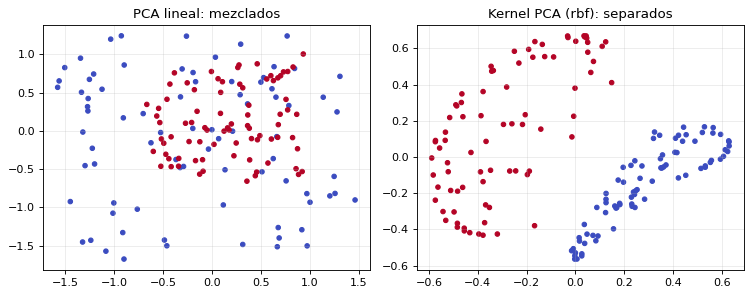

  gamma | separabilidad


------------------------
   0.01 |         0.632
   0.10 |         0.695
   1.10 |         2.669
  10.00 |         1.074
 100.00 |         0.650


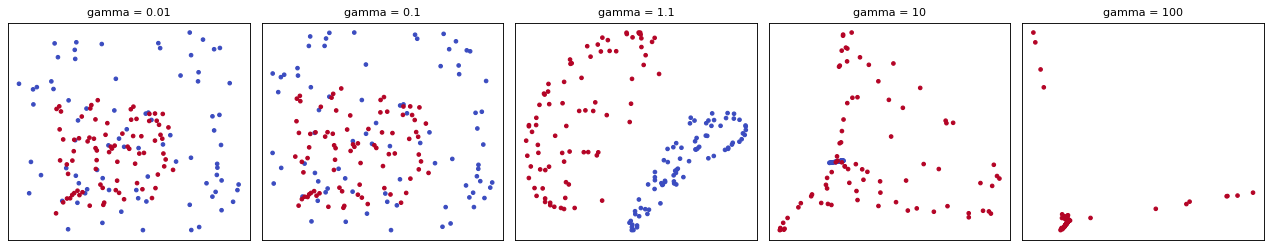


gamma muy bajo  -> el kernel se vuelve casi lineal, no gana nada
gamma muy alto  -> cada punto es su propia isla, la estructura se pierde

Limitacion: KPCA no tiene reconstruccion directa al espacio original
(problema de la preimagen). PCA clasico si reconstruye.


In [13]:
# ===========================================================================
# 12. Kernel PCA: donde PCA lineal esta condenado a fallar
# ===========================================================================
from sklearn.decomposition import KernelPCA

# Dos casquetes esfericos concentricos: NO existe direccion lineal que los separe.
y1, x1 = RNG.uniform(-1.5, 1.5, 80), RNG.uniform(-1.5, 1.5, 80)
z1 = np.sqrt(np.maximum(7 - y1**2 - x1**2, 0)) + RNG.normal(0, .01, 80)
y2, x2 = RNG.uniform(-.6, 1, 80), RNG.uniform(-.6, 1, 80)
z2 = np.sqrt(np.maximum(3 - y2**2 - x2**2, 0)) + RNG.normal(0, .01, 80)
dat   = np.vstack([np.c_[x1, y1, z1], np.c_[x2, y2, z2]])
clase = np.r_[np.zeros(80), np.ones(80)].astype(int)

def separabilidad(sc, cl):
    """Distancia entre centroides / dispersion interna promedio. Mayor = mejor."""
    c0, c1 = sc[cl == 0], sc[cl == 1]
    return np.linalg.norm(c0.mean(0) - c1.mean(0)) / ((c0.std(0).mean() + c1.std(0).mean())/2)

sc_pca  = PCA(n_components=2).fit_transform(dat)
sc_kpca = KernelPCA(n_components=2, kernel="rbf", gamma=1.1).fit_transform(dat)

print(f"separabilidad con PCA lineal : {separabilidad(sc_pca, clase):.3f}")
print(f"separabilidad con Kernel PCA : {separabilidad(sc_kpca, clase):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(9.5, 3.8))
ax[0].scatter(*sc_pca.T, c=clase, cmap="coolwarm", s=16); ax[0].set_title("PCA lineal: mezclados")
ax[1].scatter(*sc_kpca.T, c=clase, cmap="coolwarm", s=16); ax[1].set_title("Kernel PCA (rbf): separados")
plt.tight_layout(); plt.show()


# ===========================================================================
# El parametro gamma es critico (en kernlab de R se llama sigma)
# ===========================================================================
gammas = [.01, .1, 1.1, 10, 100]
fig, ax = plt.subplots(1, len(gammas), figsize=(16, 3.2))
print(f"{'gamma':>7} | {'separabilidad':>13}")
print("-"*24)
for a, g in zip(ax, gammas):
    sc = KernelPCA(n_components=2, kernel="rbf", gamma=g).fit_transform(dat)
    print(f"{g:7.2f} | {separabilidad(sc, clase):13.3f}")
    a.scatter(*sc.T, c=clase, cmap="coolwarm", s=10)
    a.set_title(f"gamma = {g}", fontsize=10); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print("\ngamma muy bajo  -> el kernel se vuelve casi lineal, no gana nada")
print("gamma muy alto  -> cada punto es su propia isla, la estructura se pierde")
print("\nLimitacion: KPCA no tiene reconstruccion directa al espacio original")
print("(problema de la preimagen). PCA clasico si reconstruye.")


<a id="t13"></a>

---
# 13. SVD (descomposición en valores singulares)

## La descomposición

**Toda** matriz $A$ de $m\times n$, sin importar su forma ni si es cuadrada, admite:

$$A = U \Sigma V^{\top}$$

- $U$ ($m\times m$, ortogonal): **vectores singulares izquierdos**
- $\Sigma$ (diagonal): **valores singulares** $\sigma_1 \geq \sigma_2 \geq \dots \geq 0$
- $V$ ($n\times n$, ortogonal): **vectores singulares derechos**

Es más general que la descomposición espectral, que solo existe para matrices cuadradas y
simétricas. La relación entre las dos:

$$U = \text{autovectores de } AA^{\top}, \qquad V = \text{autovectores de } A^{\top}A, \qquad \sigma_i = \sqrt{\lambda_i}$$

## Aproximación de rango bajo

Truncando a los primeros $r$ valores singulares:

$$A_r = U_{[:,1:r]}\,\Sigma_{[1:r,1:r]}\,V_{[:,1:r]}^{\top}$$

> **Teorema de Eckart-Young:** $A_r$ es la **mejor** aproximación de rango $r$ a $A$, en norma de
> Frobenius y espectral. Ninguna otra matriz de rango $r$ se acerca más.

Y el error se conoce **en forma cerrada**:

$$\lVert A - A_r\rVert_F = \sqrt{\sum_{i>r}\sigma_i^2}$$

Los valores singulares descartados dicen **exactamente** cuánta información se pierde, lo que
permite elegir $r$ de forma informada.

**Relación con PCA:** si $X$ está centrada, $V$ son los autovectores de la covarianza y
$\sigma_i^2/(n-1) = \lambda_i$. Por eso `prcomp` de R usa SVD internamente.

## Aplicación: information retrieval

Es el ejemplo del curso. Se construye la **matriz término-documento**: filas = términos,
columnas = documentos, entrada $(i,j)$ = frecuencia del término $i$ en el documento $j$.

Problemas de esa matriz: es enorme, es muy **dispersa** (casi todo ceros) y sufre de **sinonimia**
(palabras distintas con el mismo significado) y **polisemia** (una palabra con varios significados).

Al aplicar SVD y quedarse con rango $r$ se obtiene **Latent Semantic Indexing**: documentos y
consultas quedan representados en un espacio de **conceptos latentes** de dimensión $r$, donde los
sinónimos caen cerca.

### Búsqueda por similitud de coseno

$$\cos(v_j, q) = \frac{\langle v_j,\, q\rangle}{\lVert v_j\rVert\,\lVert q\rVert}$$

Se usa el coseno y no la distancia euclidiana porque **no depende de la longitud del documento**,
solo de su dirección, es decir, de su composición temática.

## Equivalente en R (el código del curso)

```r
library(tm)
data("crude")                          # 20 articulos sobre petroleo

tdm <- TermDocumentMatrix(crude,
         control = list(removePunctuation = TRUE, stopwords = TRUE))
tt  <- as.matrix(tdm)

ss <- svd(tt)
ss$d                                   # valores singulares
tt - ss$u %*% diag(ss$d) %*% t(ss$v)   # verificacion: debe dar ~ 0

# Aproximacion de rango k, en dos formas equivalentes
k    <- 10
ttk  <- ss$u[, 1:k] %*% diag(ss$d[1:k]) %*% t(ss$v)[1:k, ]
ttk3 <- ss$u %*% diag(c(ss$d[1:k], rep(0, length(ss$d)-k))) %*% t(ss$v)
ttk - ttk3                             # coinciden

# Consulta
k  <- 20
uu <- ss$u[, 1:k]; dd <- ss$d[1:k]; v <- ss$v[, 1:k]

q  <- ifelse(runif(nrow(tt)) >= 0.5, 1, 0)      # consulta binaria
qq <- diag(dd) %*% t(uu) %*% q                  # se proyecta al espacio reducido

cos <- v %*% qq / sqrt(diag(t(v) %*% v) * rep(t(qq) %*% qq, k))

# OJO: numpy devuelve V TRANSPUESTA, R devuelve V. Hay que transponer al traducir.
```


In [14]:
# ===========================================================================
# 13a. SVD: la descomposicion y el teorema de Eckart-Young
# ===========================================================================
A = RNG.normal(size=(8, 5))

# full_matrices=False -> version economica.
# OJO: numpy devuelve V TRANSPUESTA (Vt); svd() de R devuelve V. Hay que transponer.
U, s, Vt = np.linalg.svd(A, full_matrices=False)

print(f"A: {A.shape}   U: {U.shape}   s: {s.shape}   Vt: {Vt.shape}")
print(f"valores singulares : {np.round(s, 4)}")
print(f"error de A - U S V': {np.abs(A - U@np.diag(s)@Vt).max():.2e}")
print(f"\nautovalores de A'A : {np.round(np.sort(np.linalg.eigvalsh(A.T@A))[::-1], 4)}")
print(f"sigma^2            : {np.round(s**2, 4)}   <- son lo mismo")

# El error de la mejor aproximacion de rango k se conoce en forma CERRADA
print(f"\n{'k':>2} | {'||A-A_k||_F real':>17} | {'sqrt(sum sigma_i^2, i>k)':>25}")
print("-"*50)
for k in range(1, 5):
    A_k = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
    print(f"{k:2d} | {np.linalg.norm(A-A_k,'fro'):17.6f} | {np.sqrt((s[k:]**2).sum()):25.6f}")

# Forma alternativa: poner en CERO los sigma sobrantes. Debe dar lo mismo.
k = 3
A_k     = U[:, :k] @ np.diag(s[:k]) @ Vt[:k, :]
A_k_alt = U @ np.diag(np.r_[s[:k], np.zeros(len(s)-k)]) @ Vt
print(f"\nlas dos formas de truncar coinciden: {np.allclose(A_k, A_k_alt)}")


# ===========================================================================
# 13b. Equivalencia con PCA
# ===========================================================================
Xc = X_iris - X_iris.mean(0)                 # SVD de PCA va sobre datos CENTRADOS
U2, s2, Vt2 = np.linalg.svd(Xc, full_matrices=False)
pca4 = PCA().fit(X_iris)

print(f"V == cargas de PCA (salvo signo): {np.allclose(np.abs(Vt2.T), np.abs(pca4.components_.T))}")
print(f"sigma^2/(n-1) == autovalores    : {np.allclose(s2**2/(len(Xc)-1), pca4.explained_variance_)}")


# ===========================================================================
# 13c. Latent Semantic Indexing: busqueda por coseno
# ===========================================================================
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

docs = ["oil prices rise in the crude market",
        "crude oil production falls sharply",
        "stock market rallies after the earnings report",
        "prices of oil and gas increase again",
        "earnings report beats stock analyst expectations"]

vec = CountVectorizer(stop_words="english")
DT = vec.fit_transform(docs).toarray()        # documentos x terminos
print(f"matriz termino-documento: {DT.T.shape} (terminos x documentos), "
      f"{100*(DT == 0).mean():.0f}% ceros -> muy dispersa")

r = 2                                          # rango del espacio de conceptos
Ud, sd, Vtd = np.linalg.svd(DT, full_matrices=False)
docs_red = Ud[:, :r] * sd[:r]                  # documentos en el espacio latente

q = vec.transform(["crude oil prices"]).toarray()
q_red = q @ Vtd[:r].T                          # la consulta se PROYECTA al mismo espacio

sim = cosine_similarity(q_red, docs_red)[0]
print("\nconsulta: 'crude oil prices'")
for i in np.argsort(sim)[::-1]:
    print(f"  coseno = {sim[i]:6.3f}  |  {docs[i]}")
print("\nSe usa el coseno y no la distancia euclidiana porque NO depende de la")
print("longitud del documento, solo de su direccion, o sea de su composicion tematica.")


A: (8, 5)   U: (8, 5)   s: (5,)   Vt: (5, 5)
valores singulares : [4.1436 2.7901 1.7861 1.5498 0.839 ]
error de A - U S V': 2.22e-15

autovalores de A'A : [17.1697  7.7848  3.1903  2.4019  0.7039]
sigma^2            : [17.1697  7.7848  3.1903  2.4019  0.7039]   <- son lo mismo

 k |  ||A-A_k||_F real |  sqrt(sum sigma_i^2, i>k)
--------------------------------------------------
 1 |          3.752460 |                  3.752460
 2 |          2.509217 |                  2.509217
 3 |          1.762339 |                  1.762339
 4 |          0.839001 |                  0.839001

las dos formas de truncar coinciden: True
V == cargas de PCA (salvo signo): True
sigma^2/(n-1) == autovalores    : True
matriz termino-documento: (17, 5) (terminos x documentos), 71% ceros -> muy dispersa

consulta: 'crude oil prices'
  coseno =  1.000  |  prices of oil and gas increase again
  coseno =  0.999  |  crude oil production falls sharply
  coseno =  0.991  |  oil prices rise in the crude market
  cos

<a id="t14"></a>

---
# 14. Manifold learning: Isomap, LLE y t-SNE

## La hipótesis del manifold

Los datos de dimensión alta suelen vivir **sobre (o cerca de) una superficie de dimensión mucho
menor** embebida en ese espacio. El ejemplo canónico es la **curva S**: una superficie de 2D
enrollada dentro de $\mathbb{R}^3$.

Sobre esos datos PCA falla de forma muy específica: al proyectar linealmente **aplasta** el
manifold y pone juntos puntos que están lejos si uno se mueve *sobre la superficie*.

La distinción clave es entre dos nociones de distancia:

- **Euclidiana:** la línea recta a través del espacio ambiente, atravesando el vacío
- **Geodésica:** el camino más corto *sobre la superficie*

## Isomap

Es **MDS con distancias geodésicas**. Se puede entender como una extensión de MDS. Tres pasos:

1. **Grafo de vecindad:** conectar cada punto con sus $k$ vecinos más cercanos (localmente, euclidiano ≈ geodésico)
2. **Distancias geodésicas:** camino más corto entre todos los pares sobre ese grafo (**Dijkstra** o Floyd-Warshall)
3. **MDS clásico** sobre esa matriz de distancias

**A favor:** conceptualmente transparente, preserva la **estructura global** (las distancias
grandes son interpretables), tiene solución cerrada y proyecta datos nuevos.

**En contra:** **muy sensible a $k$**. Si $k$ es grande aparecen **atajos** que atraviesan el vacío
(*short-circuit*) y la estructura se pierde; si es pequeño el grafo se desconecta.

## LLE (Local Linear Embedding)

Supone que cada punto se puede escribir como **combinación lineal de sus vecinos**. Estima esos
pesos $W_{ij}$ en el espacio original y luego busca coordenadas de dimensión baja que conserven
**esos mismos pesos**. La idea: localmente, el manifold es plano.

| Variante | Idea |
|---|---|
| `standard` | LLE clásico |
| `ltsa` | *Local Tangent Space Alignment*: alinea espacios tangentes locales |
| `hessian` | *Hessian eigenmap*: usa la curvatura, requiere más vecinos |
| `modified` | usa varios vectores de pesos para estabilizar |

## t-SNE

Convierte distancias en **probabilidades de vecindad**: la probabilidad de que $i$ escoja a $j$
como vecino. Luego busca coordenadas en 2D cuyas probabilidades se parezcan, minimizando la
**divergencia de Kullback-Leibler**. Usa una $t$ de Student en el espacio destino, lo que da colas
pesadas y evita que todo se apiñe en el centro.

Parámetro clave: **`perplexity`**, aproximadamente el número efectivo de vecinos (típico: 5 a 50).

> **Tres advertencias sobre t-SNE que se preguntan mucho:**
> 1. Preserva **vecindarios locales**, no la estructura global. **Las distancias entre clusters y sus tamaños en un gráfico de t-SNE no significan nada.**
> 2. No es determinístico: dos corridas dan gráficos distintos.
> 3. No proyecta datos nuevos: hay que reajustar todo.

## Comparación

| Método | Preserva | Datos nuevos | Determinístico |
|---|---|---|---|
| PCA | varianza global | sí | sí |
| Isomap | distancias geodésicas globales | sí | sí |
| LLE | geometría local lineal | sí | depende |
| t-SNE | vecindarios locales | **no** | **no** |

## Equivalente en R

```r
library(vegan); library(lle); library(Rtsne)

# Isomap
dis <- dist(X)
iso <- isomap(dis, k = 10, ndim = 2)
plot(iso$points)

# LLE
# calc_k(X, m = 2, kmin = 5, kmax = 20)   # ayuda a escoger k
res <- lle(X, m = 2, k = 10)
plot(res$Y)

# t-SNE
ts <- Rtsne(X, dims = 2, perplexity = 30, max_iter = 500, check_duplicates = FALSE)
plot(ts$Y)

# PCA, para comparar: no logra desenrollar
plot(prcomp(X)$x[, 1:2])
```


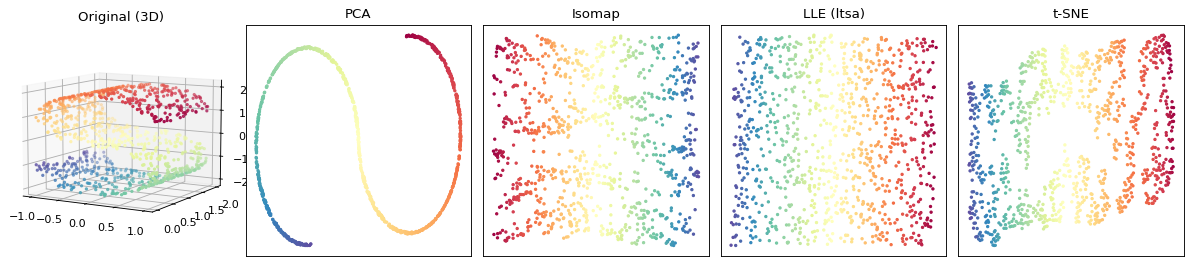

PCA aplasta el manifold: junta puntos que estan lejos SOBRE la superficie.
metodo       | |correlacion de Spearman| con la posicion real
--------------------------------------------------------------
PCA          |                                          0.916
Isomap       |                                          1.000
LLE (ltsa)   |                                          1.000
t-SNE        |                                          0.999

n_neighbors | |Spearman| | comentario
----------------------------------------------------
          4 |      0.999 | grafo casi desconectado


         10 |      1.000 | bien


         30 |      1.000 | bien


        100 |      0.943 | atajos fuera del manifold

k muy pequeno  -> el grafo de vecindad se desconecta
k muy grande   -> aparecen atajos que atraviesan el vacio (short-circuit)

t-SNE: preserva vecindarios, NO la estructura global. Las distancias entre
clusters y sus tamanos en un grafico de t-SNE no significan nada.


In [15]:
# ===========================================================================
# 14a. Manifold learning: desenrollar la curva S
# ===========================================================================
from sklearn import manifold, datasets
import warnings

S_pts, S_col = datasets.make_s_curve(1000, random_state=0)
# S_col codifica la posicion A LO LARGO de la curva: si el metodo desenrolla
# bien, el gradiente de color queda continuo y ordenado en el embedding.

S_pca = PCA(n_components=2).fit_transform(S_pts)
S_iso = manifold.Isomap(n_neighbors=10, n_components=2).fit_transform(S_pts)
S_lle = manifold.LocallyLinearEmbedding(n_neighbors=10, n_components=2,
                                        method="ltsa", random_state=0).fit_transform(S_pts)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    S_tsne = manifold.TSNE(n_components=2, perplexity=30, init="pca",
                           random_state=0).fit_transform(S_pts)

fig = plt.figure(figsize=(15, 3.4))
a3 = fig.add_subplot(1, 5, 1, projection="3d")
a3.scatter(*S_pts.T, c=S_col, cmap="Spectral", s=4); a3.view_init(elev=9, azim=-60)
a3.set_title("Original (3D)")
for j, (emb, nom) in enumerate([(S_pca, "PCA"), (S_iso, "Isomap"),
                                (S_lle, "LLE (ltsa)"), (S_tsne, "t-SNE")], start=2):
    a = fig.add_subplot(1, 5, j)
    a.scatter(*emb.T, c=S_col, cmap="Spectral", s=4)
    a.set_title(nom); a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

print("PCA aplasta el manifold: junta puntos que estan lejos SOBRE la superficie.")


# ===========================================================================
# 14b. Medir objetivamente quien desenrollo bien
# ===========================================================================
from scipy.stats import spearmanr

# Si el embedding es bueno, una coordenada debe ordenar los puntos igual que S_col
print(f"{'metodo':12} | {'|correlacion de Spearman| con la posicion real':>46}")
print("-"*62)
for nom, emb in [("PCA", S_pca), ("Isomap", S_iso), ("LLE (ltsa)", S_lle), ("t-SNE", S_tsne)]:
    rho = max(abs(spearmanr(emb[:, d], S_col).statistic) for d in range(2))
    print(f"{nom:12} | {rho:46.3f}")


# ===========================================================================
# 14c. Isomap es MUY sensible al numero de vecinos
# ===========================================================================
print(f"\n{'n_neighbors':>11} | {'|Spearman|':>10} | comentario")
print("-"*52)
for k in [4, 10, 30, 100]:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        emb = manifold.Isomap(n_neighbors=k, n_components=2).fit_transform(S_pts)
    rho = max(abs(spearmanr(emb[:, d], S_col).statistic) for d in range(2))
    nota = "grafo casi desconectado" if k < 5 else ("atajos fuera del manifold" if k > 50 else "bien")
    print(f"{k:11d} | {rho:10.3f} | {nota}")

print("\nk muy pequeno  -> el grafo de vecindad se desconecta")
print("k muy grande   -> aparecen atajos que atraviesan el vacio (short-circuit)")
print("\nt-SNE: preserva vecindarios, NO la estructura global. Las distancias entre")
print("clusters y sus tamanos en un grafico de t-SNE no significan nada.")


<a id="t15"></a>

---
# Parte 2 — Aprendizaje supervisado
# 15. EPE, MSE y el balance sesgo-varianza

## El objetivo

Encontrar una función $f$ que, dado $X$, prediga $Y$ lo mejor posible. Bajo error cuadrático la
función óptima es la **media condicional**:

$$f_{opt}(x) = E[Y \mid X = x]$$

y los datos se generan como $Y = f_{opt}(X) + \varepsilon$, con $\operatorname{Var}(\varepsilon)=\sigma^2$.

## La descomposición del EPE

Para un punto nuevo $x_0$:

$$EPE(x_0) = E\bigl[(Y - \hat{f}(x_0))^2\bigr] =
\underbrace{\sigma^2}_{\text{irreducible}} +
\underbrace{\bigl[\text{Sesgo}(\hat{f}(x_0))\bigr]^2}_{\downarrow \text{ con flexibilidad}} +
\underbrace{\operatorname{Var}(\hat{f}(x_0))}_{\uparrow \text{ con flexibilidad}}$$

| Término | Qué mide | Se reduce |
|---|---|---|
| $\sigma^2$ | ruido de la población | **nunca**: es el piso |
| Sesgo$^2$ | cuánto se aleja en promedio el modelo de la función real | subiendo la flexibilidad |
| Varianza | cuánto cambia el modelo si se cambia la muestra de entrenamiento | bajando la flexibilidad |

El balance entre los dos últimos produce la **curva en U** del error de test.

## MSE como estimador del EPE

$$MSE = \frac{1}{n}\sum_i (\hat{y}_i - y_i)^2$$

> **La regla central del curso, y la que más se pregunta:**
> - El **MSE en train siempre baja** cuando el modelo se vuelve más flexible. Con flexibilidad máxima llega a cero (memoriza). **Por eso no sirve para calibrar.**
> - El **MSE en test tiene forma de U**. Su mínimo es el nivel de flexibilidad calibrado.

## Qué es "flexibilidad" en cada modelo

| Modelo | Parámetro | Más flexible cuando |
|---|---|---|
| k vecinos | $k$ | $k$ **pequeño** |
| Kernel regression | $h$ (ventana) | $h$ **pequeño** |
| Regresión lineal | número de variables | más variables |
| Ridge, LASSO, Elastic Net | $\lambda$ | $\lambda$ **pequeño** |

> Ojo con la dirección: en k vecinos y kernel regression el parámetro es **inversamente**
> proporcional a la flexibilidad. Es un error clásico leer la curva al revés.

## Equivalente en R

```r
library(FNN)

set.seed(1)
f <- function(x) 2 + x^0.3 * cos(x/0.2)
n <- 400; x <- runif(n, 1, 5); y <- f(x) + rnorm(n, 0, 1.2)

idx <- sample(1:n, floor(0.75*n))
x_tr <- x[idx];  y_tr <- y[idx]
x_te <- x[-idx]; y_te <- y[-idx]

ks <- 1:60
mse_tr <- mse_te <- rep(0, length(ks))
for (i in seq_along(ks)) {
  mse_tr[i] <- mean((knn.reg(matrix(x_tr), matrix(x_tr), y_tr, ks[i])$pred - y_tr)^2)
  mse_te[i] <- mean((knn.reg(matrix(x_tr), matrix(x_te), y_tr, ks[i])$pred - y_te)^2)
}

plot(ks, mse_te, type = "l", col = "blue", lwd = 3,
     xlab = "k (grande = MENOS flexible)", ylab = "MSE")
lines(ks, mse_tr, col = "red", lwd = 3)
abline(h = 1.2^2, lty = 2)        # error irreducible
ks[which.min(mse_te)]
```


Menos flexible a la derecha (k grande = ventana mas ancha = mas suave):
 k  sesgo^2  varianza  sigma^2    EPE
 1   0.0030    1.0005      1.0 2.0035
 3   0.0017    0.3496      1.0 1.3513
 5   0.0031    0.2190      1.0 1.2221
10   0.0207    0.1334      1.0 1.1542
20   0.1864    0.1002      1.0 1.2865
40   0.9978    0.0615      1.0 2.0593
80   0.9024    0.0272      1.0 1.9296

k optimo segun el EPE: 10


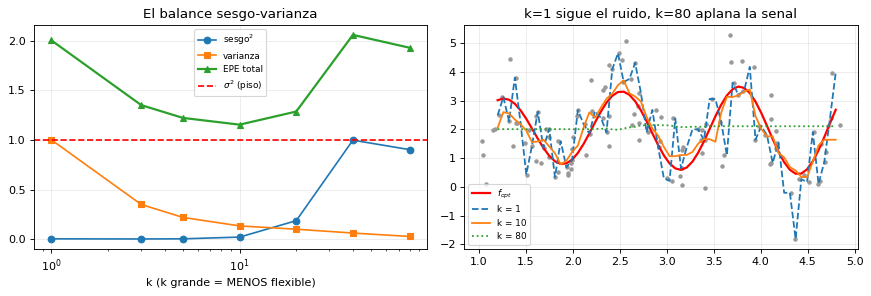

In [16]:
# ===========================================================================
# 15. Descomposicion EPE = sigma^2 + sesgo^2 + varianza, medida empiricamente
# ===========================================================================
# Se puede hacer porque f_optima y sigma son CONOCIDOS: es una simulacion.
from sklearn.neighbors import KNeighborsRegressor

sigma, n_train, n_rep = 1.0, 120, 300
x_eval = np.linspace(1.2, 4.8, 60).reshape(-1, 1)
f_eval = f_optima(x_eval.ravel())

ks = [1, 3, 5, 10, 20, 40, 80]
filas = []
for k in ks:
    preds = np.empty((n_rep, len(x_eval)))
    for r in range(n_rep):                          # muchas muestras de la MISMA poblacion
        xr = RNG.uniform(1, 5, n_train)
        yr = f_optima(xr) + RNG.normal(0, sigma, n_train)
        preds[r] = KNeighborsRegressor(k).fit(xr.reshape(-1, 1), yr).predict(x_eval)

    sesgo2   = np.mean((preds.mean(0) - f_eval)**2)  # error sistematico
    varianza = np.mean(preds.var(0))                 # sensibilidad a la muestra
    filas.append((k, sesgo2, varianza, sigma**2, sesgo2 + varianza + sigma**2))

tab = pd.DataFrame(filas, columns=["k", "sesgo^2", "varianza", "sigma^2", "EPE"])
print("Menos flexible a la derecha (k grande = ventana mas ancha = mas suave):")
print(tab.round(4).to_string(index=False))
print(f"\nk optimo segun el EPE: {tab.loc[tab.EPE.idxmin(), 'k']:.0f}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(ks, tab["sesgo^2"], "o-", label="sesgo$^2$")
ax[0].plot(ks, tab["varianza"], "s-", label="varianza")
ax[0].plot(ks, tab["EPE"], "^-", lw=2, label="EPE total")
ax[0].axhline(sigma**2, color="r", ls="--", label="$\\sigma^2$ (piso)")
ax[0].set_xscale("log"); ax[0].set_xlabel("k (k grande = MENOS flexible)")
ax[0].set_title("El balance sesgo-varianza"); ax[0].legend(fontsize=8)

# Como se ve cada nivel de flexibilidad
xr = RNG.uniform(1, 5, n_train); yr = f_optima(xr) + RNG.normal(0, sigma, n_train)
ax[1].plot(xr, yr, "o", ms=3, color="0.6")
ax[1].plot(x_eval, f_eval, "r", lw=2, label="$f_{opt}$")
for k, estilo in [(1, "--"), (10, "-"), (80, ":")]:
    ax[1].plot(x_eval, KNeighborsRegressor(k).fit(xr.reshape(-1,1), yr).predict(x_eval),
               estilo, lw=1.6, label=f"k = {k}")
ax[1].legend(fontsize=8); ax[1].set_title("k=1 sigue el ruido, k=80 aplana la senal")
plt.tight_layout(); plt.show()


<a id="t16"></a>

---
# 16. Kernel regression y k vecinos

## Kernel regression rectangular

Para predecir $Y^*$ dado un $X^*$ particular, se buscan los $X_i$ de entrenamiento que caen en el
intervalo $[X^*-h,\,X^*+h]$ y se promedian sus $Y_i$:

$$\hat{f}(X^*) = \frac{\sum_i \mathbb{1}\bigl(\lvert X_i - X^*\rvert \le h\bigr)\,Y_i}
{\sum_i \mathbb{1}\bigl(\lvert X_i - X^*\rvert \le h\bigr)}$$

donde $\mathbb{1}(\cdot)$ es la función indicadora: vale 1 cuando la condición es cierta y 0 cuando
es falsa.

## Relación con k vecinos

Son primos. La diferencia está en qué se fija:

| | Se fija | Varía |
|---|---|---|
| **k vecinos** | el **número** de puntos | el ancho de la ventana, según la densidad local |
| **Kernel regression** | el **ancho** de la ventana | el número de puntos que caen dentro |

En ambos la predicción es un **promedio local** de los $Y$.

## El parámetro h

Controla la flexibilidad de forma **inversa**:

- **$h$ grande:** la ventana abarca muchos puntos y la función estimada queda muy suave → **sesgo**, falta flexibilidad
- **$h$ pequeño:** la ventana abarca pocos puntos y la curva sigue el ruido → **varianza**, exceso de flexibilidad

No se calibra a ojo: se recorre una secuencia de $h$, se calcula el MSE en test para cada uno y se
toma el que lo minimiza.

## El problema de las colas

Cerca de los extremos del rango de $X$ la ventana queda **incompleta** y hay menos puntos, así que
el estimador es menos confiable. En el código esto aparece como el `max(..., 0.1)` del
denominador, que evita dividir por cero cuando no cae ningún punto dentro de la ventana.

> **El error más común al programarlo:** confundir los argumentos. En
> `kernelreg(xstar, X, Y, h)`, los argumentos 2 y 3 son **siempre los datos de entrenamiento**.
> Lo único que cambia entre el MSE de train y el de test es **dónde se predice** (el primer
> argumento).

## Equivalente en R

```r
kernelreg <- function(xstar, X, Y, h) {
  sapply(xstar, function(xs) {
    dentro <- abs(xs - X) <= h
    sum(Y[dentro]) / max(sum(dentro), 0.1)
  })
}

xstar <- seq(1, 5, by = 0.01)
plot(x_tr, y_tr, pch = 16, cex = 0.4)
curve(f, 1, 5, col = "red", lwd = 3, add = TRUE)
lines(xstar, kernelreg(xstar, x_tr, y_tr, 0.4),  col = "blue", lwd = 2)  # sesgo
lines(xstar, kernelreg(xstar, x_tr, y_tr, 0.03), col = "green", lwd = 2) # varianza

# Funciones ya implementadas en R
ksmooth(x_tr, y_tr, kernel = "box", bandwidth = 2*h, x.points = xstar)
loess(y_tr ~ x_tr, span = 0.2)          # regresion local polinomial

library(FNN)
knn.reg(train = matrix(x_tr), test = matrix(xstar), y = y_tr, k = 10)$pred
```


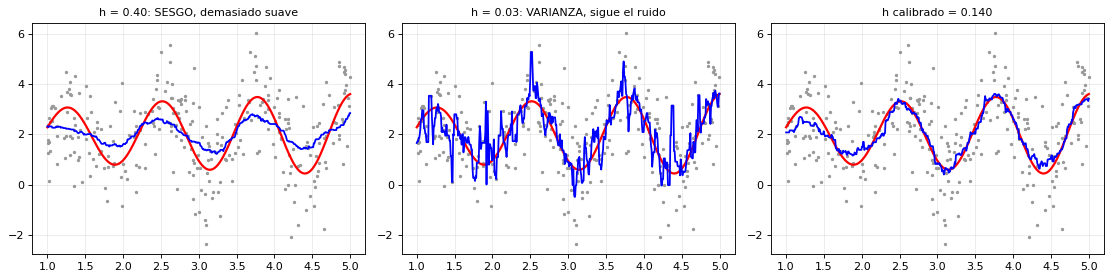

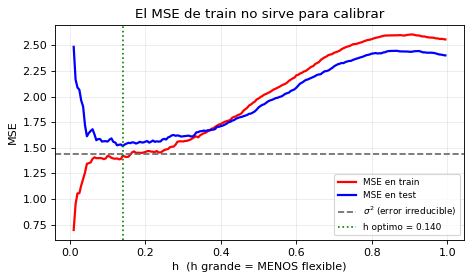

MSE de train con h -> 0 : 0.6986   (tiende a cero: memoriza)
MSE minimo en test      : 1.5165   con h = 0.140
sigma^2 (piso teorico)  : 1.4400
k =  1  ->  MSE en test =   7461.0
k =  3  ->  MSE en test =   3987.1
k = 10  ->  MSE en test =   3443.7
k = 30  ->  MSE en test =   3200.4

k vecinos fija el NUMERO de puntos (ventana de ancho variable).
Kernel regression fija el ANCHO de la ventana (numero de puntos variable).


In [17]:
# ===========================================================================
# 16a. Kernel regression rectangular, implementado desde la formula
# ===========================================================================
def kernelreg(xstar, X, Y, h):
    """Promedio de los Y dentro de la ventana [x*-h, x*+h].
    xstar = puntos donde se predice.  X, Y = datos de ENTRENAMIENTO."""
    pred = np.zeros(len(xstar))
    for i, xs in enumerate(xstar):
        dentro = np.abs(xs - X) <= h
        # max(..., 0.1) evita dividir por cero cuando la ventana queda vacia
        pred[i] = Y[dentro].sum() / max(dentro.sum(), 0.1)
    return pred

sigma = 1.2
n = 400
x = RNG.uniform(1, 5, n)
y = f_optima(x) + RNG.normal(0, sigma, n)

# Particion train / test
idx = RNG.permutation(n)
n_tr = int(.75*n)
x_tr, y_tr = x[idx[:n_tr]], y[idx[:n_tr]]
x_te, y_te = x[idx[n_tr:]], y[idx[n_tr:]]

rejilla = np.linspace(1, 5, 500)
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
for a, h, titulo in [(ax[0], .40, "h = 0.40: SESGO, demasiado suave"),
                     (ax[1], .03, "h = 0.03: VARIANZA, sigue el ruido"),
                     (ax[2], None, "h calibrado")]:
    a.plot(x_tr, y_tr, "o", ms=2, color="0.6")
    a.plot(rejilla, f_optima(rejilla), "r", lw=2)
    if h:
        a.plot(rejilla, kernelreg(rejilla, x_tr, y_tr, h), "b", lw=1.6)
    a.set_title(titulo, fontsize=10)


# ===========================================================================
# 16b. La curva en U: MSE de train contra MSE de test
# ===========================================================================
hh = np.arange(.01, 1.0, .005)
mse_tr = np.array([np.mean((kernelreg(x_tr, x_tr, y_tr, h) - y_tr)**2) for h in hh])
mse_te = np.array([np.mean((kernelreg(x_te, x_tr, y_tr, h) - y_te)**2) for h in hh])

h_opt = hh[mse_te.argmin()]
ax[2].plot(rejilla, kernelreg(rejilla, x_tr, y_tr, h_opt), "b", lw=1.6)
ax[2].set_title(f"h calibrado = {h_opt:.3f}", fontsize=10)
plt.tight_layout(); plt.show()

plt.figure(figsize=(6, 3.6))
plt.plot(hh, mse_tr, "r", lw=2, label="MSE en train")
plt.plot(hh, mse_te, "b", lw=2, label="MSE en test")
plt.axhline(sigma**2, color="0.4", ls="--", label="$\\sigma^2$ (error irreducible)")
plt.axvline(h_opt, color="g", ls=":", label=f"h optimo = {h_opt:.3f}")
plt.xlabel("h  (h grande = MENOS flexible)"); plt.ylabel("MSE")
plt.legend(fontsize=8); plt.title("El MSE de train no sirve para calibrar")
plt.tight_layout(); plt.show()

print(f"MSE de train con h -> 0 : {mse_tr[0]:.4f}   (tiende a cero: memoriza)")
print(f"MSE minimo en test      : {mse_te.min():.4f}   con h = {h_opt:.3f}")
print(f"sigma^2 (piso teorico)  : {sigma**2:.4f}")


# ===========================================================================
# 16c. El primo cercano: k vecinos
# ===========================================================================
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor

XTrain, XTest, yTrain, yTest = train_test_split(X_diab, y_diab, test_size=.33, random_state=0)
for k in [1, 3, 10, 30]:
    pred = KNeighborsRegressor(n_neighbors=k).fit(XTrain, yTrain).predict(XTest)
    print(f"k = {k:2d}  ->  MSE en test = {np.mean((pred - yTest)**2):8.1f}")

print("\nk vecinos fija el NUMERO de puntos (ventana de ancho variable).")
print("Kernel regression fija el ANCHO de la ventana (numero de puntos variable).")


<a id="t17"></a>

---
# 17. Validación cruzada

## El problema con una sola partición

1. El MSE de test **depende de qué partición salió**. Con otra semilla da otro número.
2. Se desperdicia información: el modelo final solo se entrena con una fracción de los datos.

## Validación cruzada en K folds

Se parte la muestra en $K$ bloques del mismo tamaño y, $K$ veces, se entrena con $K-1$ folds y se
evalúa en el restante:

$$CV_{(K)} = \frac{1}{K}\sum_{j=1}^{K} MSE_j$$

Cada observación se usa **exactamente una vez** para evaluar y $K-1$ veces para entrenar.

## Elección de K

| $K$ | Sesgo del estimador | Varianza | Costo |
|---|---|---|---|
| pequeño (5) | mayor (entrena con menos datos) | menor | barato |
| grande (10) | menor | mayor | medio |
| $K = n$ (**LOOCV**) | mínimo | alta | caro |

El estándar de la práctica es **$K = 5$ o $K = 10$**.

## Para qué se usa

Principalmente para **calibrar el parámetro de flexibilidad**: se recorre una rejilla de valores,
se calcula el CV para cada uno y se escoge el que minimiza el error. Es exactamente lo que hacen
por dentro `RidgeCV`, `LassoCV`, `ElasticNetCV` y `cv.glmnet`.

## La advertencia que se cobra caro

> Toda transformación que use información de la respuesta o de **toda** la muestra (escalamiento,
> selección de variables, imputación) debe hacerse **dentro de cada fold**, no antes. Si se hace
> antes, la información del fold de evaluación se filtra al entrenamiento y el error estimado sale
> **optimistamente bajo**. En sklearn eso se resuelve con un `Pipeline`.

## Detalle de sklearn

`cross_val_score` siempre **maximiza**, así que reporta el MSE con signo cambiado:
`scoring="neg_mean_squared_error"`. Para obtener el MSE hay que invertir el signo.

## Equivalente en R

```r
# A mano
K <- 10
set.seed(0)
folds <- sample(rep(1:K, length.out = nrow(datos)))

mse_fold <- rep(0, K)
for (j in 1:K) {
  modelo <- lm(y ~ ., data = datos[folds != j, ])
  pred   <- predict(modelo, datos[folds == j, ])
  mse_fold[j] <- mean((datos$y[folds == j] - pred)^2)
}
mean(mse_fold)

# Con boot
library(boot)
modelo <- glm(Grad.Rate ~ ., data = College[, -1])
cv.glm(College[, -1], modelo, K = 10)$delta[1]   # estimador CV
cv.glm(College[, -1], modelo)$delta[1]           # sin K = LOOCV

# Con caret: calibrar k vecinos por CV, escalando DENTRO de cada fold
library(caret)
ajuste <- train(Grad.Rate ~ ., data = College[, -1], method = "knn",
                trControl = trainControl(method = "cv", number = 10),
                tuneGrid  = data.frame(k = 1:30),
                preProcess = c("center", "scale"))
ajuste$bestTune
plot(ajuste)
```


MSE en test con 20 particiones distintas del MISMO dataset:
  minimo 2796   maximo 4092   rango 1297
  media  3367   desviacion 309

El 'MSE en test' depende de que particion salio. Por eso se promedia sobre folds.
CV a mano        : 3286.57
cross_val_score  : 3286.57
coinciden        : True

variabilidad entre folds: sd = 437.1  (por eso se reporta el promedio)


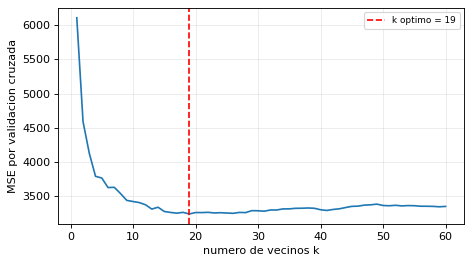

k optimo = 19   MSE CV = 3238.9


GridSearchCV encuentra lo mismo: {'n_neighbors': 19}  MSE = 3238.9

K = 5 o 10 es el estandar. K = n es LOOCV: sesgo minimo, varianza alta, caro.
ADVERTENCIA: escalar o seleccionar variables debe hacerse DENTRO de cada fold
(con un Pipeline). Si se hace antes, el error de CV sale optimistamente bajo.


In [18]:
# ===========================================================================
# 17a. Por que una sola particion no basta
# ===========================================================================
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

mses = []
for semilla in range(20):
    XTr, XTe, yTr, yTe = train_test_split(X_diab, y_diab, test_size=.33, random_state=semilla)
    pred = KNeighborsRegressor(10).fit(XTr, yTr).predict(XTe)
    mses.append(np.mean((pred - yTe)**2))

print(f"MSE en test con 20 particiones distintas del MISMO dataset:")
print(f"  minimo {min(mses):.0f}   maximo {max(mses):.0f}   rango {max(mses)-min(mses):.0f}")
print(f"  media  {np.mean(mses):.0f}   desviacion {np.std(mses):.0f}")
print("\nEl 'MSE en test' depende de que particion salio. Por eso se promedia sobre folds.")


# ===========================================================================
# 17b. Los folds a mano y con cross_val_score (deben coincidir)
# ===========================================================================
K = 10
kf = KFold(n_splits=K, shuffle=True, random_state=0)

errores = []
for i_tr, i_te in kf.split(X_diab):          # OJO: split() devuelve INDICES, no datos
    modelo = KNeighborsRegressor(10).fit(X_diab[i_tr], y_diab[i_tr])
    errores.append(np.mean((modelo.predict(X_diab[i_te]) - y_diab[i_te])**2))

# scoring="neg_..." porque sklearn siempre MAXIMIZA: reporta el MSE con signo cambiado
auto = -cross_val_score(KNeighborsRegressor(10), X_diab, y_diab, cv=kf,
                        scoring="neg_mean_squared_error")

print(f"CV a mano        : {np.mean(errores):.2f}")
print(f"cross_val_score  : {auto.mean():.2f}")
print(f"coinciden        : {np.allclose(np.mean(errores), auto.mean())}")
print(f"\nvariabilidad entre folds: sd = {auto.std():.1f}  (por eso se reporta el promedio)")


# ===========================================================================
# 17c. Calibrar k por validacion cruzada
# ===========================================================================
lista_k = range(1, 61)
mse_cv = [-cross_val_score(KNeighborsRegressor(k), X_diab, y_diab, cv=10,
                           scoring="neg_mean_squared_error").mean() for k in lista_k]
k_opt = list(lista_k)[int(np.argmin(mse_cv))]

plt.figure(figsize=(6, 3.4))
plt.plot(list(lista_k), mse_cv)
plt.axvline(k_opt, color="r", ls="--", label=f"k optimo = {k_opt}")
plt.xlabel("numero de vecinos k"); plt.ylabel("MSE por validacion cruzada")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

print(f"k optimo = {k_opt}   MSE CV = {min(mse_cv):.1f}")

# La version automatica de todo lo anterior
busca = GridSearchCV(KNeighborsRegressor(), {"n_neighbors": list(lista_k)},
                     cv=10, scoring="neg_mean_squared_error").fit(X_diab, y_diab)
print(f"GridSearchCV encuentra lo mismo: {busca.best_params_}  MSE = {-busca.best_score_:.1f}")

print("\nK = 5 o 10 es el estandar. K = n es LOOCV: sesgo minimo, varianza alta, caro.")
print("ADVERTENCIA: escalar o seleccionar variables debe hacerse DENTRO de cada fold")
print("(con un Pipeline). Si se hace antes, el error de CV sale optimistamente bajo.")


<a id="t18"></a>

---
# 18. Selección de variables

## Por qué se hace

En un modelo lineal, **la cantidad de variables es el parámetro de flexibilidad**: más variables
significa más flexibilidad, más varianza y menos sesgo. Hay que encontrar una forma sistemática de
escoger el subconjunto que mejor predice.

## Los dos métodos

| Método | Cómo | Número de modelos | Garantía |
|---|---|---|---|
| **Exhaustivo** | compara **todos** los subconjuntos posibles | $2^p - 1$ (**exponencial**) | encuentra el óptimo |
| **Forward** | empieza con una variable y agrega de a una, **dejando fijas** las que ya entraron | $p(p+1)/2$ (**cuadrático**) | heurística, no garantiza el óptimo |

Con $p=20$: el exhaustivo son más de un millón de modelos, el forward son 210. También existe
**backward**, que empieza con todas y va quitando.

> Forward **nunca deshace** una variable que ya entró. Por eso puede quedarse en un subconjunto
> peor que el óptimo, aunque en la práctica suele acercarse.

## Las métricas para comparar modelos de distinto tamaño

No se puede usar el $R^2$ crudo ni el RSS, porque **siempre mejoran** al agregar variables. Hay que
penalizar el tamaño:

$$R^2_{adj} = 1 - \frac{(1-R^2)(n-1)}{n-d-1} \qquad \text{(MAXIMIZAR)}$$

$$C_p = \frac{1}{n}\bigl(RSS + 2\,d\,\hat{\sigma}^2\bigr) \qquad \text{(minimizar)}$$

$$AIC = n\log(RSS/n) + 2(d+1) \qquad \text{(minimizar)}$$

$$BIC = n\log(RSS/n) + \log(n)\,(d+1) \qquad \text{(minimizar)}$$

| Criterio | Dirección | Penalización por parámetro |
|---|---|---|
| $R^2$ ajustado | **máximo** | moderada |
| $C_p$ de Mallows | mínimo | $2\hat{\sigma}^2$ |
| AIC | mínimo | $2$ |
| BIC | mínimo | $\log(n)$, **la más fuerte** |
| MSE en test o CV | mínimo | ninguna, se mide directo |

> **$\log(n) > 2$ para todo $n > 7$**, así que **el BIC siempre elige un modelo igual o más
> pequeño que el AIC**. Esa relación se pregunta mucho.

## Equivalente en R (el código del curso)

```r
library(ISLR); library(leaps)

Hitters <- na.omit(Hitters)         # regsubsets NO maneja datos faltantes

# El metodo se cambia con UN argumento
subs <- regsubsets(Salary ~ ., Hitters, nvmax = 19, method = "exhaustive")
# method = "forward" / "backward"

res <- summary(subs)
res$cp          # Cp de Mallows del mejor modelo de cada tamano
res$bic
res$adjr2
res$rss         # siempre baja: NO sirve para comparar tamanos

which.min(res$cp); which.min(res$bic); which.max(res$adjr2)

coef(subs, which.min(res$bic))      # coeficientes del modelo elegido
plot(subs, scale = "bic")           # que variables entran en cada modelo

# Seleccion paso a paso por AIC (o BIC con k = log(n))
completo <- lm(Salary ~ ., data = Hitters)
nulo     <- lm(Salary ~ 1, data = Hitters)
step(nulo, scope = list(lower = nulo, upper = completo), direction = "forward")
step(completo, direction = "backward", k = log(nrow(Hitters)))   # BIC

AIC(completo); BIC(completo)
```


p = 10 variables
  exhaustivo: 2^p - 1 = 1,023 modelos      (crece EXPONENCIAL)
  forward   : p(p+1)/2 = 55 modelos          (crece CUADRATICO)
  con p = 30 el exhaustivo serian 1,073,741,823 modelos



Mejor modelo de cada tamano (busqueda exhaustiva):
    R2_adj       Cp      AIC      BIC
d                                    
1     0.32  3967.14  2455.07  2462.45
2     0.44  3315.78  2401.85  2412.92
3     0.45  3218.82  2393.05  2407.81
4     0.46  3166.86  2388.18  2406.64
5     0.48  3057.81  2377.50  2399.64
6     0.49  3061.47  2377.82  2403.65
7     0.49  3064.74  2378.09  2407.61
8     0.49  3076.17  2379.18  2412.40
9     0.49  3088.55  2380.37  2417.27
10    0.48  3108.89  2382.36  2422.96

R2 ajustado -> MAXIMO en d = 7
Cp          -> minimo en d = 5
AIC         -> minimo en d = 5
BIC         -> minimo en d = 5   <- BIC siempre elige igual o mas pequeno


Con d = 5 (el que elige el BIC):
  exhaustivo elige: ['sex', 'bmi', 'bp', 's3', 's5']
  forward    elige: ['sex', 'bmi', 'bp', 's3', 's5']
  Aqui coincidieron, pero no esta garantizado:
  forward es una heuristica, nunca deshace una variable que ya entro.



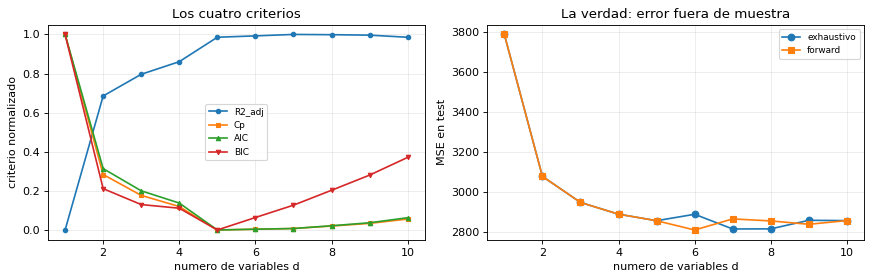

MSE en test del modelo elegido por BIC: 2857.0
MSE en test del modelo completo       : 2857.6


In [19]:
# ===========================================================================
# 18a. Metodo forward y metodo exhaustivo
# ===========================================================================
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import train_test_split
import itertools

XTr, XTe, yTr, yTe = train_test_split(X_diab, y_diab, test_size=.33, random_state=18)
n_tr, p = XTr.shape

print(f"p = {p} variables")
print(f"  exhaustivo: 2^p - 1 = {2**p - 1:,} modelos      (crece EXPONENCIAL)")
print(f"  forward   : p(p+1)/2 = {p*(p+1)//2} modelos          (crece CUADRATICO)")
print(f"  con p = 30 el exhaustivo serian {2**30 - 1:,} modelos\n")

# --- Los cuatro criterios para cada tamano de modelo ----------------------
sigma2_full = np.sum((LinearRegression().fit(XTr, yTr).predict(XTr) - yTr)**2)/(n_tr - p - 1)

def criterios(cols):
    """Devuelve R2 ajustado, Cp de Mallows, AIC y BIC del modelo con esas columnas."""
    d = len(cols)
    mod = LinearRegression().fit(XTr[:, cols], yTr)
    rss = np.sum((mod.predict(XTr[:, cols]) - yTr)**2)
    r2  = mod.score(XTr[:, cols], yTr)
    r2a = 1 - (1 - r2)*(n_tr - 1)/(n_tr - d - 1)
    cp  = (rss + 2*d*sigma2_full)/n_tr
    aic = n_tr*np.log(rss/n_tr) + 2*(d + 1)
    bic = n_tr*np.log(rss/n_tr) + np.log(n_tr)*(d + 1)   # penaliza log(n) > 2
    return r2a, cp, aic, bic, rss

# Exhaustivo de verdad: el mejor subconjunto de CADA tamano
mejor_por_tamano = {}
for d in range(1, p+1):
    mejor = min(itertools.combinations(range(p), d),
                key=lambda c: criterios(list(c))[4])   # menor RSS dentro del tamano
    mejor_por_tamano[d] = list(mejor)

tab = pd.DataFrame([criterios(mejor_por_tamano[d])[:4] for d in range(1, p+1)],
                   columns=["R2_adj", "Cp", "AIC", "BIC"], index=range(1, p+1))
tab.index.name = "d"
print("Mejor modelo de cada tamano (busqueda exhaustiva):")
print(tab.round(2).to_string())
print(f"\nR2 ajustado -> MAXIMO en d = {tab.R2_adj.idxmax()}")
print(f"Cp          -> minimo en d = {tab.Cp.idxmin()}")
print(f"AIC         -> minimo en d = {tab.AIC.idxmin()}")
print(f"BIC         -> minimo en d = {tab.BIC.idxmin()}   <- BIC siempre elige igual o mas pequeno")


# ===========================================================================
# 18b. Forward con sklearn y comparacion en test
# ===========================================================================
fwd_por_tamano = {}
for d in range(1, p):
    sfs = SequentialFeatureSelector(LinearRegression(), n_features_to_select=d,
                                    direction="forward", cv=5).fit(XTr, yTr)
    fwd_por_tamano[d] = list(np.where(sfs.get_support())[0])
fwd_por_tamano[p] = list(range(p))

d_bic = int(tab.BIC.idxmin())
print(f"Con d = {d_bic} (el que elige el BIC):")
print(f"  exhaustivo elige: {[var_diab[i] for i in mejor_por_tamano[d_bic]]}")
print(f"  forward    elige: {[var_diab[i] for i in fwd_por_tamano[d_bic]]}")
igual = mejor_por_tamano[d_bic] == fwd_por_tamano[d_bic]
print(f"  {'Aqui coincidieron' if igual else 'Aqui NO coincidieron'}, pero no esta garantizado:")
print("  forward es una heuristica, nunca deshace una variable que ya entro.\n")

def mse_test(cols):
    mod = LinearRegression().fit(XTr[:, cols], yTr)
    return np.mean((mod.predict(XTe[:, cols]) - yTe)**2)

mse_exh = [mse_test(mejor_por_tamano[d]) for d in range(1, p+1)]
mse_fwd = [mse_test(fwd_por_tamano[d])   for d in range(1, p+1)]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for col, estilo in zip(["R2_adj", "Cp", "AIC", "BIC"], ["o-", "s-", "^-", "v-"]):
    serie = tab[col]
    ax[0].plot(tab.index, (serie - serie.min())/(serie.max() - serie.min()), estilo,
               ms=4, label=col)
ax[0].set_xlabel("numero de variables d"); ax[0].set_ylabel("criterio normalizado")
ax[0].legend(fontsize=8); ax[0].set_title("Los cuatro criterios")
ax[1].plot(range(1, p+1), mse_exh, "o-", label="exhaustivo")
ax[1].plot(range(1, p+1), mse_fwd, "s-", label="forward")
ax[1].set_xlabel("numero de variables d"); ax[1].set_ylabel("MSE en test")
ax[1].legend(fontsize=8); ax[1].set_title("La verdad: error fuera de muestra")
plt.tight_layout(); plt.show()

print(f"MSE en test del modelo elegido por BIC: {mse_test(mejor_por_tamano[d_bic]):.1f}")
print(f"MSE en test del modelo completo       : {mse_test(list(range(p))):.1f}")


<a id="t19"></a>

---
# 19. Ridge, LASSO y Elastic Net

## El problema

Mínimos cuadrados resuelve $\hat{\beta} = \arg\min \sum_i (Y_i - \beta^{\top}X_i)^2$. Si hay
**redundancia de información** entre predictoras (multicolinealidad), la estimación tiene mucha
varianza: los $\beta$ toman valores absolutos enormes, los signos se vuelven inestables y el
modelo predice mal fuera de muestra.

## La solución: penalizar el tamaño de $\beta$

$$\hat{\beta} = \arg\min_{\beta} \sum_i (Y_i - \beta^{\top}X_i)^2 + \lambda\,\lVert\beta\rVert$$

con $\lambda > 0$ el **parámetro de penalización**, que es el parámetro de flexibilidad de estos
modelos. La diferencia entre los tres métodos es **cómo se define la norma**.

### Ridge — norma 2

$$\arg\min_{\beta}\ \sum_i (Y_i - \beta^{\top}X_i)^2 + \lambda \sum_j \beta_j^2$$

Encoge los coeficientes hacia cero pero **nunca los hace exactamente cero**. Conserva todas las
variables. Funciona muy bien con multicolinealidad: **reparte el peso** entre variables
correlacionadas.

### LASSO — norma 1

$$\arg\min_{\beta}\ \sum_i (Y_i - \beta^{\top}X_i)^2 + \lambda \sum_j \lvert\beta_j\rvert$$

**Sí hace exactamente cero** algunos coeficientes, o sea que **selecciona variables**
automáticamente y produce modelos dispersos. Entre variables muy correlacionadas tiende a escoger
una y anular las demás, de forma algo arbitraria.

> *Por qué:* la bola $L_1$ tiene **esquinas** sobre los ejes, y el óptimo restringido cae en una
> esquina. La bola $L_2$ es redonda: no tiene esquinas, así que nunca toca un eje exactamente.

### Elastic Net — combinación

$$\arg\min_{\beta}\ \sum_i (Y_i - \beta^{\top}X_i)^2 + \lambda\Bigl[(1-\alpha)\sum_j \beta_j^2 + \alpha\sum_j \lvert\beta_j\rvert\Bigr]$$

Dos parámetros: $\lambda$ y $\alpha$. Con $\alpha=0$ es Ridge, con $\alpha=1$ es LASSO. En el medio
selecciona variables como LASSO pero maneja mejor los **grupos** de variables correlacionadas,
tendiendo a incluirlas o excluirlas juntas.

## La confusión de nombres (trampa clásica de parcial)

| Concepto | En la fórmula del curso | En `glmnet` (R) | En sklearn |
|---|---|---|---|
| Fuerza de la penalización | $\lambda$ | `lambda` | **`alpha`** |
| Mezcla entre normas | $\alpha$ | **`alpha`** | **`l1_ratio`** |

El `alpha` de sklearn **no** es el `alpha` de glmnet. En los dos, sin embargo, el valor que
selecciona variables es el que da peso a la norma 1: `alpha=1` en glmnet, `l1_ratio=1` en sklearn.

## Escalamiento

Las tres penalizan el **tamaño** de los coeficientes, así que dependen de la escala de las
variables. **Hay que estandarizar antes.** `glmnet` lo hace por defecto (`standardize = TRUE`);
sklearn **no**.

## Cómo se ve el efecto de $\lambda$

El gráfico típico pone $\lambda$ en el eje horizontal (en escala logarítmica, casi siempre
invertido) y los coeficientes en el vertical. Todos convergen a cero cuando $\lambda$ crece: en
LASSO **tocan** cero y se quedan ahí, en Ridge solo se acercan asintóticamente.

## Equivalente en R (el código del curso)

```r
library(glmnet)

# glmnet NO acepta data frames ni formulas: hay que armar la matriz
X     <- model.matrix(Grad.Rate ~ ., train)[, -1]   # el [,-1] quita el intercepto
Xtest <- model.matrix(Grad.Rate ~ ., test)[, -1]
y     <- train$Grad.Rate

# El tipo de penalizacion se controla SOLO con alpha
cvmod <- cv.glmnet(X, y, alpha = 0)     # 0 = Ridge
cvmod <- cv.glmnet(X, y, alpha = 1)     # 1 = LASSO
cvmod <- cv.glmnet(X, y, alpha = 0.3)   # Elastic Net

cvmod$lambda.min     # minimiza el error de CV
cvmod$lambda.1se     # el mayor lambda a 1 error estandar del minimo: modelo mas simple
plot(cvmod)

mod <- glmnet(X, y, alpha = 1, lambda = cvmod$lambda.min)
coef(mod)            # en LASSO los ceros aparecen como PUNTO

pred <- predict(mod, Xtest)
mean((ytest - pred)^2)

# Trayectorias de los coeficientes: ajustar SIN fijar lambda
plot(glmnet(X, y, alpha = 1), xvar = "lambda", label = TRUE)
```


modelo         |    lambda | coef = 0 |  R2 train |  MSE test
------------------------------------------------------------
OLS            |       nan |        0 |     0.502 |    2857.6
Ridge          |    0.0732 |        0 |     0.497 |    2932.7
LASSO          |    0.0420 |        2 |     0.498 |    2885.3
Elastic Net    |    0.0003 |        0 |     0.498 |    2928.1

OJO con este resultado: diabetes ya viene escalado y con poca redundancia,
asi que penalizar NO mejora el MSE. Las penalizaciones ganan cuando hay
multicolinealidad o p grande, como se ve abajo.

Ridge encoge pero NUNCA hace cero: conserva las 10 variables.
LASSO SI hace cero: selecciona variables automaticamente.

Variables que sobreviven en LASSO: ['age', 'sex', 'bmi', 'bp', 's1', 's3', 's5', 's6']


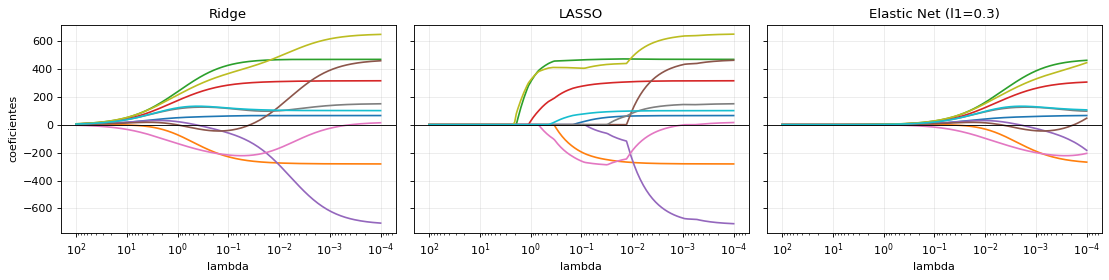

En LASSO los coeficientes TOCAN cero y se quedan ahi (esquinas de la bola L1).
En Ridge solo se acercan asintoticamente (la bola L2 no tiene esquinas).
correlacion entre x1 y x2: 1.00000

modelo     |    beta1 |    beta2 |    suma   (la verdad: 3 + 2 = 5)
----------------------------------------------------
OLS        |    15.47 |   -10.47 |    5.00
Ridge      |     2.49 |     2.49 |    4.98
LASSO      |     4.97 |     0.00 |    4.97

OLS se vuelve inestable: reparte pesos grandes y de signo opuesto entre gemelas.
Ridge reparte el peso entre las dos y estabiliza la suma.
LASSO escoge UNA de las dos y anula la otra, de forma algo arbitraria.



l1_ratio escogido: 0.1   (1.0 = LASSO puro, 0 = Ridge)
lambda escogido  : 0.0003
coeficientes en cero: 0 de 10
MSE en test      : 2930.7

RECORDAR: las tres penalizan el TAMANO de los coeficientes, asi que
dependen de la escala. Hay que estandarizar antes (glmnet de R lo hace solo).


In [20]:
# ===========================================================================
# 19a. Las tres penalizaciones, calibradas por validacion cruzada
# ===========================================================================
from sklearn.linear_model import (Ridge, Lasso, ElasticNet,
                                  RidgeCV, LassoCV, ElasticNetCV, LinearRegression)

# En sklearn el parametro de penalizacion se llama alpha (es el LAMBDA de la teoria)
# y la mezcla entre normas se llama l1_ratio (es el ALPHA de glmnet).
alphas = np.logspace(-4, 2, 200)          # escala LOG: el efecto es multiplicativo

ridge = RidgeCV(alphas=alphas).fit(XTr, yTr)
lasso = LassoCV(alphas=alphas, max_iter=50000, random_state=0).fit(XTr, yTr)
enet  = ElasticNetCV(alphas=alphas, l1_ratio=.3, max_iter=50000,
                     cv=10, random_state=0).fit(XTr, yTr)
ols   = LinearRegression().fit(XTr, yTr)

print(f"{'modelo':14} | {'lambda':>9} | {'coef = 0':>8} | {'R2 train':>9} | {'MSE test':>9}")
print("-"*60)
for nom, mod in [("OLS", ols), ("Ridge", ridge), ("LASSO", lasso), ("Elastic Net", enet)]:
    lam = getattr(mod, "alpha_", np.nan)
    ceros = int((np.abs(mod.coef_) < 1e-10).sum())
    mse = np.mean((mod.predict(XTe) - yTe)**2)
    print(f"{nom:14} | {lam:9.4f} | {ceros:8d} | {mod.score(XTr, yTr):9.3f} | {mse:9.1f}")

print("\nOJO con este resultado: diabetes ya viene escalado y con poca redundancia,")
print("asi que penalizar NO mejora el MSE. Las penalizaciones ganan cuando hay")
print("multicolinealidad o p grande, como se ve abajo.")
print("\nRidge encoge pero NUNCA hace cero: conserva las 10 variables.")
print("LASSO SI hace cero: selecciona variables automaticamente.")
print(f"\nVariables que sobreviven en LASSO: {[var_diab[i] for i in np.where(lasso.coef_ != 0)[0]]}")


# ===========================================================================
# 19b. Trayectorias de los coeficientes
# ===========================================================================
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), sharey=True)
for a, (nom, clase, extra) in zip(ax, [("Ridge", Ridge, {}),
                                       ("LASSO", Lasso, {"max_iter": 50000}),
                                       ("Elastic Net (l1=0.3)", ElasticNet,
                                        {"l1_ratio": .3, "max_iter": 50000})]):
    coefs = np.array([clase(alpha=al, **extra).fit(XTr, yTr).coef_ for al in alphas])
    a.plot(alphas, coefs)
    a.set_xscale("log"); a.invert_xaxis()      # flexibilidad creciente hacia la derecha
    a.axhline(0, color="k", lw=.8)
    a.set_xlabel("lambda"); a.set_title(nom)
ax[0].set_ylabel("coeficientes")
plt.tight_layout(); plt.show()

print("En LASSO los coeficientes TOCAN cero y se quedan ahi (esquinas de la bola L1).")
print("En Ridge solo se acercan asintoticamente (la bola L2 no tiene esquinas).")


# ===========================================================================
# 19c. Donde Ridge realmente gana: multicolinealidad
# ===========================================================================
n = 100
x1 = RNG.normal(size=n)
x2 = x1 + RNG.normal(0, .002, n)                # practicamente identica a x1
Xm = np.c_[x1, x2, RNG.normal(size=(n, 3))]
ym = 3*x1 + 2*x2 + RNG.normal(0, .5, n)         # el efecto REAL conjunto es 5

print(f"correlacion entre x1 y x2: {np.corrcoef(x1, x2)[0,1]:.5f}\n")
print(f"{'modelo':10} | {'beta1':>8} | {'beta2':>8} | {'suma':>7}   (la verdad: 3 + 2 = 5)")
print("-"*52)
for nom, mod in [("OLS", LinearRegression()), ("Ridge", Ridge(alpha=1.0)),
                 ("LASSO", Lasso(alpha=.05))]:
    b = mod.fit(Xm, ym).coef_
    print(f"{nom:10} | {b[0]:8.2f} | {b[1]:8.2f} | {b[0]+b[1]:7.2f}")

print("\nOLS se vuelve inestable: reparte pesos grandes y de signo opuesto entre gemelas.")
print("Ridge reparte el peso entre las dos y estabiliza la suma.")
print("LASSO escoge UNA de las dos y anula la otra, de forma algo arbitraria.")


# ===========================================================================
# 19d. Calibrar lambda y l1_ratio al tiempo
# ===========================================================================
enet2 = ElasticNetCV(l1_ratio=[.1, .3, .5, .7, .9, .95, 1.0],
                     alphas=np.logspace(-4, 2, 100),
                     cv=10, max_iter=50000, random_state=0).fit(XTr, yTr)
print(f"\nl1_ratio escogido: {enet2.l1_ratio_}   (1.0 = LASSO puro, 0 = Ridge)")
print(f"lambda escogido  : {enet2.alpha_:.4f}")
print(f"coeficientes en cero: {int((enet2.coef_ == 0).sum())} de {p}")
print(f"MSE en test      : {np.mean((enet2.predict(XTe) - yTe)**2):.1f}")
print("\nRECORDAR: las tres penalizan el TAMANO de los coeficientes, asi que")
print("dependen de la escala. Hay que estandarizar antes (glmnet de R lo hace solo).")


<a id="trampas"></a>

---
# Resumen final — las trampas que hay que recordar

## Errores de implementación

| # | Trampa | Por qué |
|---|---|---|
| 1 | **Escalar antes** de K-Means, jerárquico, DBSCAN, PCA y cualquier penalización | todos miden distancias o tamaños de coeficientes: la variable de mayor rango domina |
| 2 | En DBSCAN el ruido es **`-1` en sklearn** y **`0` en R** | son convenciones distintas del mismo concepto |
| 3 | `negative_outlier_factor_` de LOF está **negado** | más negativo = más atípico. En R `lof()` devuelve el LOF directo, donde mayor que 1 = atípico |
| 4 | `decision_function` de Isolation Forest también invierte el signo | **negativo = anómalo**, al revés de la $s(x,m)$ de la teoría |
| 5 | `cross_val_score` devuelve el MSE **con signo negativo** | sklearn siempre maximiza: `neg_mean_squared_error` |
| 6 | `glmnet` no acepta data frames | hay que pasar por `model.matrix(y ~ ., datos)[, -1]` |
| 7 | `regsubsets` no maneja datos faltantes | correr `na.omit()` antes |
| 8 | `pca.components_` tiene una **fila** por componente, `prcomp$rotation` una **columna** | están transpuestas entre sí |
| 9 | `numpy.linalg.svd` devuelve **$V^{\top}$**, `svd()` de R devuelve **$V$** | hay que transponer al traducir código |
| 10 | `mahalanobis()` de R ya devuelve la distancia **al cuadrado** | no hay que elevarla otra vez |
| 11 | El `alpha` de sklearn es el $\lambda$ de la teoría | la mezcla de normas es `l1_ratio` |

## Errores conceptuales

| # | Trampa | Por qué |
|---|---|---|
| 12 | **K-Means siempre devuelve $K$ grupos** | nunca dice "aquí no hay clusters". Hay que verificarlo aparte |
| 13 | **Silhouette, CH y DB premian a K-Means sobre DBSCAN en anillos** | asumen grupos compactos alrededor de un centroide; con anillos concéntricos los centroides coinciden |
| 14 | **En iris las métricas prefieren $K=2$, no 3** | describen la geometría de $X$, no la taxonomía: *versicolor* y *virginica* se traslapan |
| 15 | **El Z-Score se enmascara con GRUPOS de outliers** | ellos mismos inflan la $sd$. Usar el Z modificado (mediana + MAD) |
| 16 | **Z-Score por variable $\neq$ Mahalanobis** | un punto puede ser típico en cada variable y atípico en conjunto por romper la correlación |
| 17 | **En análisis factorial un p-value ALTO significa modelo ADECUADO** | es al revés de la lectura habitual |
| 18 | **`factanal(iris, 2)` falla y debe fallar** | con $p=4$ el máximo identificable es 1 factor. No es un bug |
| 19 | **En t-SNE, tamaños y distancias entre clusters no significan nada** | solo los vecindarios son fiables. Tampoco es determinístico ni proyecta datos nuevos |
| 20 | **El MSE de train no sirve para calibrar** | siempre baja con la flexibilidad y llega a cero |
| 21 | **En k vecinos y kernel regression el parámetro va al revés** | $k$ o $h$ **grande** significa modelo **menos** flexible |
| 22 | **El BIC siempre elige un modelo igual o más pequeño que el AIC** | $\log(n) > 2$ para todo $n > 7$ |
| 23 | **Escalar o seleccionar variables ANTES de la validación cruzada** | filtra información del fold de evaluación y el error sale optimistamente bajo. Usar `Pipeline` |
| 24 | **Ridge nunca hace un coeficiente exactamente cero** | la bola $L_2$ no tiene esquinas. Solo LASSO y Elastic Net seleccionan variables |
| 25 | **Kernel PCA no tiene reconstrucción directa** | volver de $Z$ a $X$ es el problema de la preimagen. PCA clásico sí reconstruye |
| 26 | **MDS clásico con distancias euclidianas es PCA** | cambia la entrada ($D$ en vez de $X$), no el resultado. La rotación y la reflexión son inherentes |

---

*Repositorio completo con la explicación extendida y el código de cada tema en R y Python:
`temas/01-fundamentos/` … `temas/19-ridge-lasso-elasticnet/`.*
